# Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from torchvision.transforms import ToPILImage
from math import log10
import pandas as pd
import copy
import cv2
from PIL import Image
import os
import seaborn as sns
from torch.nn.utils import spectral_norm
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr
from scipy.linalg import sqrtm

# Dataset Loading & Preprocessing

100%|██████████| 170498071/170498071 [00:04<00:00, 40175898.09it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


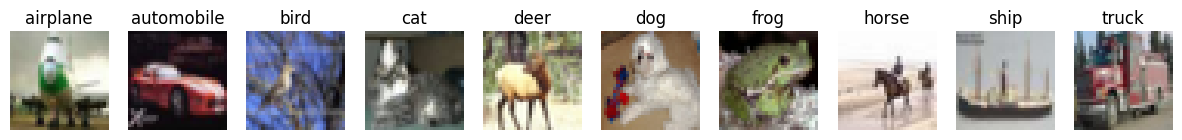

Training Data Distribution:


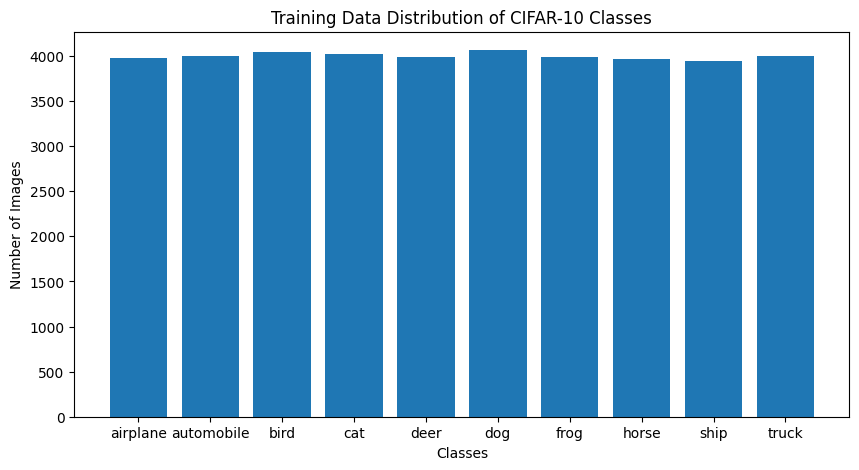

Validation Data Distribution:


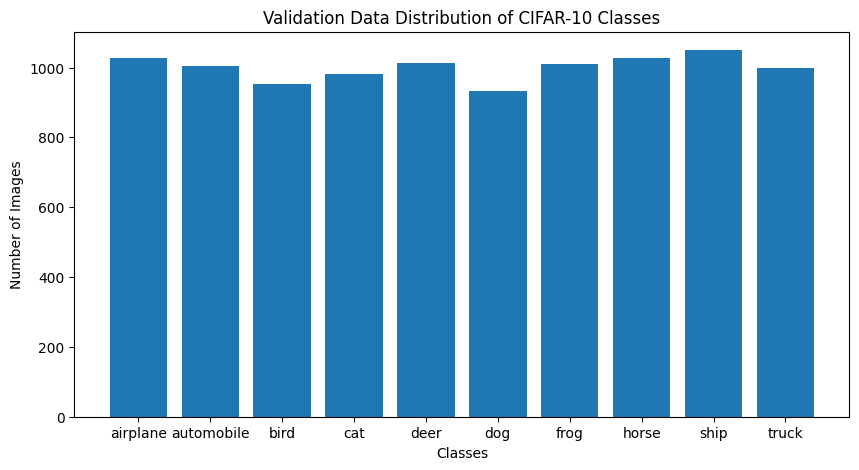

Testing Data Distribution:


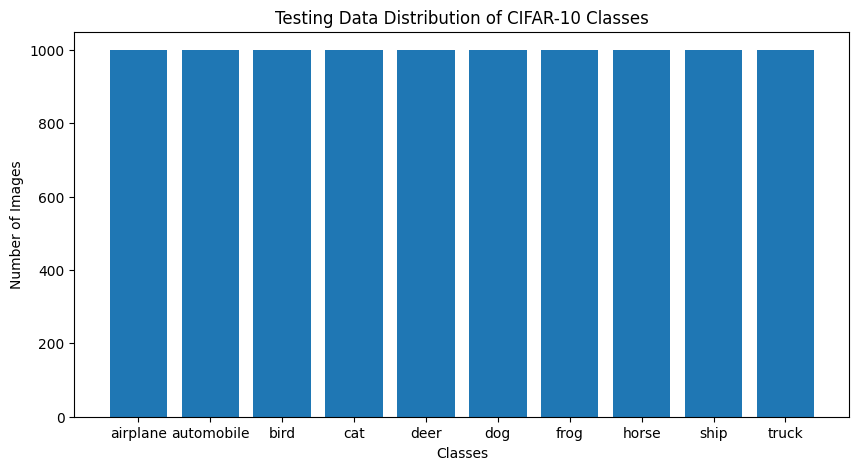

In [1]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Define CIFAR-10 classes
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Define transformations
# Training transformations include random horizontal flipping for augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Validation and testing transformations (only normalization)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CIFAR-10 dataset with transformations applied
train_val_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_test_transform)

# Split the train_val_dataset into training and validation sets (e.g., 80-20 split)
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

# Apply validation transformations to the validation dataset
val_dataset.dataset.transform = val_test_transform

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Displaying one sample image from each class and data distribution
def show_sample_images():
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    shown_classes = set()
    for images, labels in train_loader:
        for img, label in zip(images, labels):
            if len(shown_classes) == 10:
                break
            if label.item() not in shown_classes:
                img = img / 2 + 0.5  # unnormalize
                npimg = img.numpy()
                axes[label.item()].imshow(np.transpose(npimg, (1, 2, 0)))
                axes[label.item()].set_title(classes[label.item()])
                axes[label.item()].axis('off')
                shown_classes.add(label.item())
        if len(shown_classes) == 10:
            break
    plt.show()

show_sample_images()

# Plotting the data distribution in the training set
def show_data_distribution(loader, dataset_type="Training"):
    class_counts = np.zeros(10)
    for _, labels in loader:
        for label in labels:
            class_counts[label] += 1

    plt.figure(figsize=(10, 5))
    plt.bar(classes, class_counts)
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.title(f'{dataset_type} Data Distribution of CIFAR-10 Classes')
    plt.show()

# Show distribution in training, validation, and test datasets
print("Training Data Distribution:")
show_data_distribution(train_loader, "Training")
print("Validation Data Distribution:")
show_data_distribution(val_loader, "Validation")
print("Testing Data Distribution:")
show_data_distribution(test_loader, "Testing")


# Masking Function for Inpainting

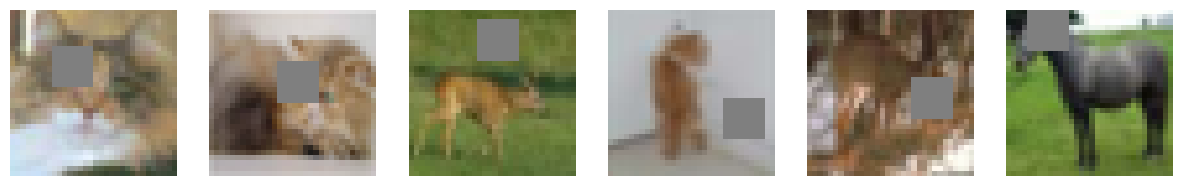

In [13]:
# Masking function
def apply_random_mask(images, mask_size=8):
    mask = torch.ones_like(images)
    for i in range(images.size(0)):
        x, y = np.random.randint(0, images.size(2) - mask_size), np.random.randint(0, images.size(3) - mask_size)
        mask[i, :, x:x+mask_size, y:y+mask_size] = 0
        images[i, :, x:x+mask_size, y:y+mask_size] = 0
    return images, mask

# Display some masked images
def show_masked_images():
    images, _ = next(iter(train_loader))
    masked_images, _ = apply_random_mask(images.clone())
    fig, axes = plt.subplots(1, 6, figsize=(15, 5))
    for i in range(6):
        axes[i].imshow(np.transpose(masked_images[i] / 2 + 0.5, (1, 2, 0)))
        axes[i].axis("off")
    plt.show()

show_masked_images()

# 1) Vanilla GAN with Encoder-Decoder Generator

In [3]:
# Define Generator and Discriminator models
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

Epoch [1/50] - Generator Loss: 0.1415, Discriminator Loss: 0.4608, Validation Loss: 0.1059


/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:232: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch [2/50] - Generator Loss: 0.1017, Discriminator Loss: 0.5249, Validation Loss: 0.0884
Epoch [3/50] - Generator Loss: 0.0917, Discriminator Loss: 0.5363, Validation Loss: 0.0783
Epoch [4/50] - Generator Loss: 0.0854, Discriminator Loss: 0.5230, Validation Loss: 0.0767
Epoch [5/50] - Generator Loss: 0.0809, Discriminator Loss: 0.5201, Validation Loss: 0.0718
Epoch [6/50] - Generator Loss: 0.0774, Discriminator Loss: 0.4956, Validation Loss: 0.0669
Epoch [7/50] - Generator Loss: 0.0747, Discriminator Loss: 0.4558, Validation Loss: 0.0674
Epoch [8/50] - Generator Loss: 0.0724, Discriminator Loss: 0.4557, Validation Loss: 0.0642
Epoch [9/50] - Generator Loss: 0.0704, Discriminator Loss: 0.4436, Validation Loss: 0.0598
Epoch [10/50] - Generator Loss: 0.0677, Discriminator Loss: 0.4674, Validation Loss: 0.0587
Epoch [11/50] - Generator Loss: 0.0662, Discriminator Loss: 0.4267, Validation Loss: 0.0580
Epoch [12/50] - Generator Loss: 0.0640, Discriminator Loss: 0.4216, Validation Loss: 0.0

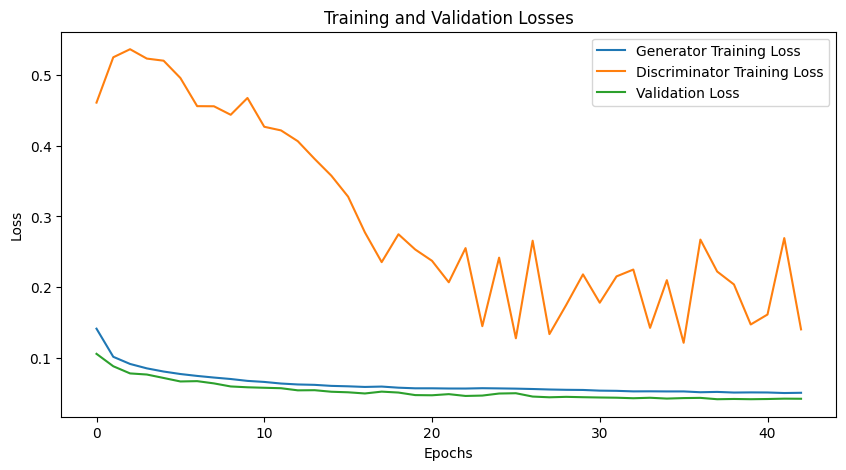

In [4]:
# Instantiate models, loss functions, optimizers, and schedulers
generator = Generator().to(device)
discriminator = Discriminator().to(device)

reconstruction_loss_fn = nn.L1Loss()
adversarial_loss_fn = nn.BCELoss()

gen_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

scheduler_gen = optim.lr_scheduler.StepLR(gen_optimizer, step_size=10, gamma=0.1)
scheduler_disc = optim.lr_scheduler.StepLR(disc_optimizer, step_size=10, gamma=0.1)

# Training parameters
num_epochs = 50
patience = 5
min_delta = 0.001
best_val_loss = float("inf")
no_improvement_epochs = 0
lambda_reconstruction = 0.999
lambda_adversarial = 0.001

# Lists to store losses for plotting
train_g_losses = []
train_d_losses = []
val_losses = []

# Training loop with early stopping
for epoch in range(num_epochs):
    generator.train()
    discriminator.train()
    
    g_running_loss = 0.0
    d_running_loss = 0.0
    
    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        masked_images, _ = apply_random_mask(real_images.clone())
        masked_images = masked_images.to(device)
        
        real_labels = torch.ones(real_images.size(0), device=device)
        fake_labels = torch.zeros(real_images.size(0), device=device)
        
        # Discriminator Training
        disc_optimizer.zero_grad()
        real_outputs = discriminator(real_images)
        d_real_loss = adversarial_loss_fn(real_outputs, real_labels)
        
        fake_images = generator(masked_images)
        fake_outputs = discriminator(fake_images.detach())
        d_fake_loss = adversarial_loss_fn(fake_outputs, fake_labels)
        
        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        disc_optimizer.step()
        
        # Generator Training
        gen_optimizer.zero_grad()
        
        g_reconstruction_loss = reconstruction_loss_fn(fake_images, real_images)
        fake_outputs = discriminator(fake_images)
        g_adversarial_loss = adversarial_loss_fn(fake_outputs, real_labels)
        
        g_loss = (lambda_reconstruction * g_reconstruction_loss) + (lambda_adversarial * g_adversarial_loss)
        g_loss.backward()
        gen_optimizer.step()
        
        g_running_loss += g_loss.item()
        d_running_loss += d_loss.item()
    
    avg_g_loss = g_running_loss / len(train_loader)
    avg_d_loss = d_running_loss / len(train_loader)
    train_g_losses.append(avg_g_loss)
    train_d_losses.append(avg_d_loss)
    
    # Validation phase
    generator.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for val_images, _ in val_loader:
            val_images = val_images.to(device)
            masked_val_images, _ = apply_random_mask(val_images.clone())
            masked_val_images = masked_val_images.to(device)
            
            val_reconstructed_images = generator(masked_val_images)
            val_loss = reconstruction_loss_fn(val_reconstructed_images, val_images)
            val_running_loss += val_loss.item()
    
    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Generator Loss: {avg_g_loss:.4f}, Discriminator Loss: {avg_d_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")
    
    scheduler_gen.step(avg_val_loss)
    scheduler_disc.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        no_improvement_epochs = 0
    else:
        no_improvement_epochs += 1
    
    if no_improvement_epochs >= patience:
        print("Early stopping triggered.")
        break

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_g_losses, label='Generator Training Loss')
plt.plot(train_d_losses, label='Discriminator Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Losses")
plt.show()


In [14]:
# Directory to save the model
model_dir = './saved_models'
os.makedirs(model_dir, exist_ok=True)

# Save both Generator and Discriminator models along with their optimizers
def save_model(generator, discriminator, gen_optimizer, disc_optimizer, epoch, filename="gan_inpainting.pth"):
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'gen_optimizer_state_dict': gen_optimizer.state_dict(),
        'disc_optimizer_state_dict': disc_optimizer.state_dict(),
    }, os.path.join(model_dir, filename))
    print("Model saved successfully.")

# Call the save_model function at the end of training
save_model(generator, discriminator, gen_optimizer, disc_optimizer, epoch)


Model saved successfully.


In [15]:
# Load the model function
def load_model(generator, discriminator, gen_optimizer, disc_optimizer, filename="gan_inpainting.pth"):
    checkpoint = torch.load(os.path.join(model_dir, filename), map_location=device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    gen_optimizer.load_state_dict(checkpoint['gen_optimizer_state_dict'])
    disc_optimizer.load_state_dict(checkpoint['disc_optimizer_state_dict'])
    epoch = checkpoint['epoch']
    print(f"Model loaded successfully. Resuming from epoch {epoch}.")
    return epoch

# Reload the model and optimizer states
start_epoch = load_model(generator, discriminator, gen_optimizer, disc_optimizer)

Model loaded successfully. Resuming from epoch 42.


/tmp/ipykernel_30/3476241328.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(model_dir, filename), map_location=device)


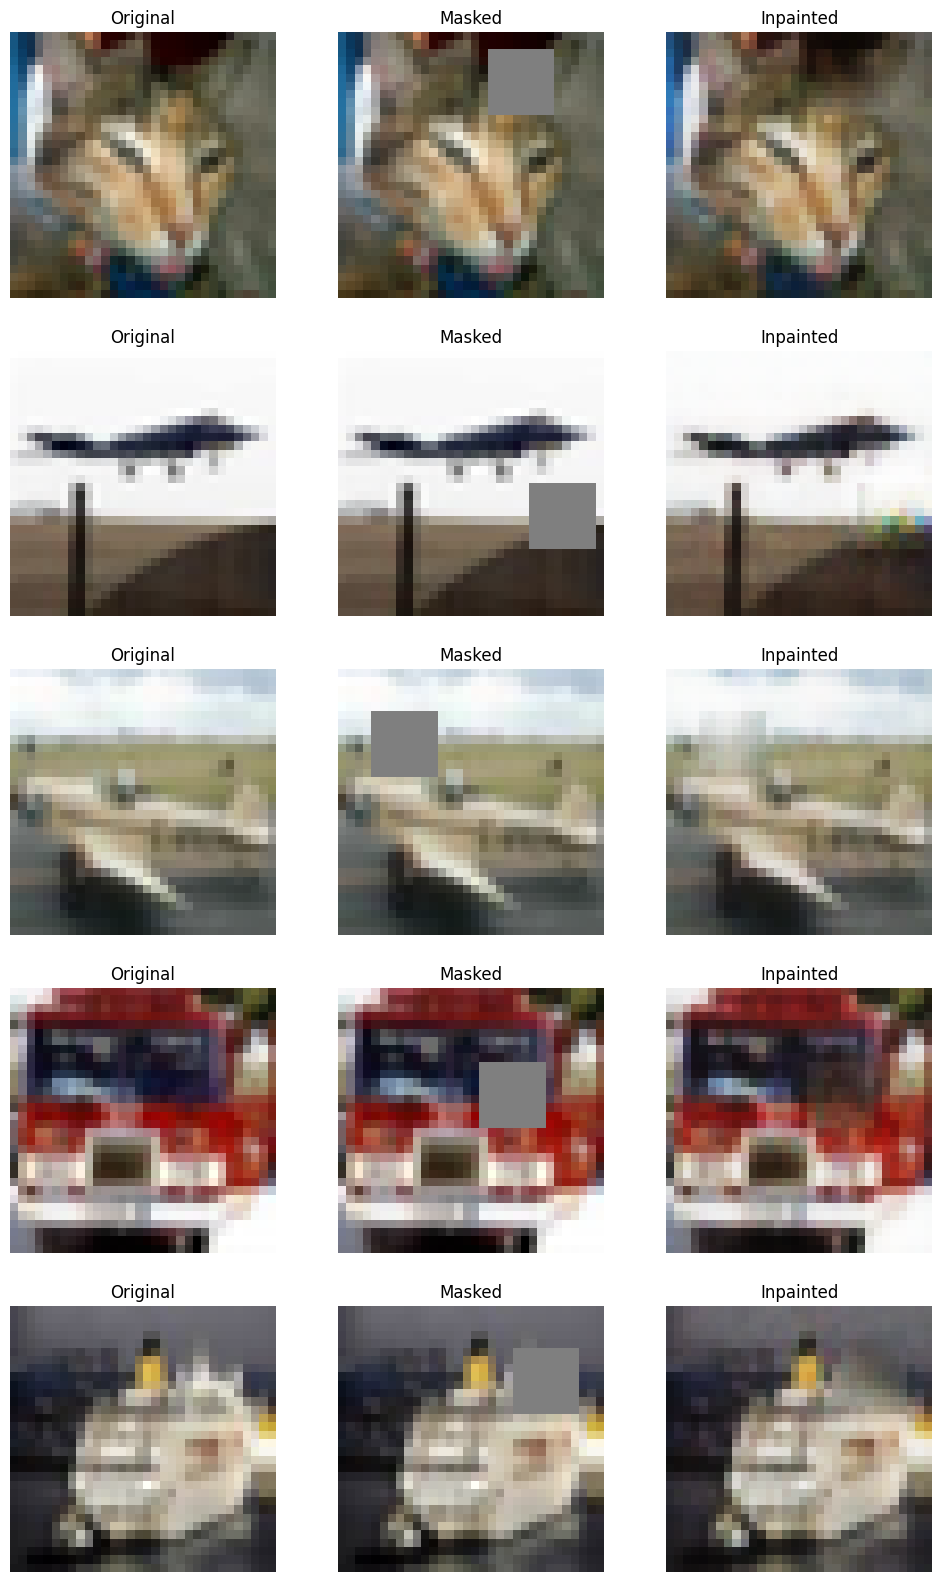

In [5]:
# Qualitative Evaluation
def visualize_inpainting_results(model, data_loader, num_images=5):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    
    with torch.no_grad():
        for i, (images, _) in enumerate(data_loader):
            if i == num_images:
                break
            images = images.to(device)
            masked_images, _ = apply_random_mask(images.clone())
            inpainted_images = model(masked_images)
            
            for j in range(images.size(0)):
                if j >= num_images:
                    break
                axes[j, 0].imshow(np.transpose(images[j].cpu().numpy() / 2 + 0.5, (1, 2, 0)))
                axes[j, 0].set_title("Original")
                axes[j, 1].imshow(np.transpose(masked_images[j].cpu().numpy() / 2 + 0.5, (1, 2, 0)))
                axes[j, 1].set_title("Masked")
                axes[j, 2].imshow(np.transpose(inpainted_images[j].cpu().numpy() / 2 + 0.5, (1, 2, 0)))
                axes[j, 2].set_title("Inpainted")
                axes[j, 0].axis("off")
                axes[j, 1].axis("off")
                axes[j, 2].axis("off")
    plt.show()

visualize_inpainting_results(generator, test_loader)

In [12]:
# Load InceptionV3 for FID calculation
inception = inception_v3(pretrained=True, transform_input=False).to(device)
inception.eval()

def calculate_reconstruction_loss(model, data_loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in data_loader:
            images = images.to(device)
            masked_images, _ = apply_random_mask(images)
            masked_images = masked_images.to(device)
            inpainted_images = model(masked_images)
            loss = F.l1_loss(inpainted_images, images)
            total_loss += loss.item()
    return total_loss / len(data_loader)

# PSNR calculation
def calculate_psnr(original, generated):
    mse = F.mse_loss(generated, original)
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()

# Evaluate on test set
reconstruction_loss = calculate_reconstruction_loss(generator, test_loader)
print(f"Average Reconstruction Loss (L1): {reconstruction_loss:.4f}")

# Calculate FID on test set
real_images, generated_images = next(iter(test_loader))
real_images, _ = apply_random_mask(real_images.to(device))
generated_images = generator(real_images)

# Calculate PSNR on test set
psnr_score = calculate_psnr(real_images, generated_images)
print(f"PSNR Score: {psnr_score:.2f} dB")

Average Reconstruction Loss (L1): 0.0512
PSNR Score: 18.87 dB


# 2) Partial Convolution-based GAN

In [37]:
class PartialConvGenerator(nn.Module):
    def __init__(self):
        super(PartialConvGenerator, self).__init__()
        
        # Encoding layers (channels double at each layer)
        self.enc1 = PartialConv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.enc2 = PartialConv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(128, 256, kernel_size=3, stride=2, padding=1)

        # Bottleneck layer
        self.bottleneck = PartialConv2d(256, 256, kernel_size=3, stride=2, padding=1)

        # Decoding layers (match channels with corresponding encoding layers)
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(256, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True)
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True)
        )
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Final output layer to reduce channels to match input image
        self.output_layer = nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1)

    def forward(self, x, mask):
        # Encoding
        e1, mask1 = self.enc1(x, mask)    # 3 -> 64 channels
        e2, mask2 = self.enc2(e1, mask1)  # 64 -> 128 channels
        e3, mask3 = self.enc3(e2, mask2)  # 128 -> 256 channels
        
        # Bottleneck
        bottleneck, _ = self.bottleneck(e3, mask3)  # 256 channels, ignore final mask
        
        # Decoding with skip connections (no mask required in decoders)
        d3 = self.dec3(bottleneck) + e3   # 256 channels
        d2 = self.dec2(d3) + e2           # 128 channels
        d1 = self.dec1(d2) + e1           # 64 channels
        
        # Final output
        out = self.output_layer(d1)       # 64 -> 3 channels

        return out

# Discriminator for GAN
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.conv_layers(x)

class PartialConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(PartialConv2d, self).__init__()
        self.input_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.mask_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        
        # Initialize mask conv to fill weights with ones and freeze parameters
        nn.init.constant_(self.mask_conv.weight, 1.0)
        for param in self.mask_conv.parameters():
            param.requires_grad = False

    def forward(self, x, mask):
        # Perform convolution on input and mask
        x_out = self.input_conv(x * mask)
        mask_out = self.mask_conv(mask)
        
        # Avoid division by zero, normalize output
        eps = 1e-8
        mask_out = torch.where(mask_out < eps, torch.tensor(1.0, device=mask_out.device), mask_out)
        x_out = x_out / mask_out
        
        # Update mask
        new_mask = torch.where(mask_out >= 1, torch.tensor(1.0, device=mask_out.device), mask_out)
        
        return x_out, new_mask

In [38]:
# Initialize models
generator = PartialConvGenerator().to(device)
discriminator = Discriminator().to(device)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Loss functions
adversarial_loss = nn.BCELoss()
reconstruction_loss = nn.L1Loss()

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(g_optimizer, step_size=20, gamma=0.1)

# Early stopping setup
early_stop_patience = 5
best_loss = float("inf")
patience_counter = 0

# Training loop
num_epochs = 50

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    generator.train()
    d_running_loss, g_running_loss = 0.0, 0.0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        masked_images, mask = apply_random_mask(real_images.clone())
        masked_images, mask = masked_images.to(device), mask.to(device)

        # Train discriminator
        d_optimizer.zero_grad()
        
        # Define target labels and reshape to match discriminator output
        real_labels = torch.ones((real_images.size(0), 1, 1, 1), device=device)
        fake_labels = torch.zeros((real_images.size(0), 1, 1, 1), device=device)


        real_output = discriminator(real_images)
        real_loss = adversarial_loss(real_output, real_labels)

        fake_images = generator(masked_images, mask)
        fake_output = discriminator(fake_images.detach())
        fake_loss = adversarial_loss(fake_output, fake_labels)
        
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        d_optimizer.step()
        
        # Train generator
        g_optimizer.zero_grad()
        fake_output = discriminator(fake_images)
        adv_loss = adversarial_loss(fake_output, real_labels)
        rec_loss = reconstruction_loss(fake_images, real_images)
        g_loss = adv_loss + 0.1 * rec_loss
        g_loss.backward()
        g_optimizer.step()
        
        d_running_loss += d_loss.item()
        g_running_loss += g_loss.item()

    scheduler.step()

    train_losses.append((d_running_loss, g_running_loss))

    # Print losses per epoch
    print(f"Epoch {epoch+1}/{num_epochs}, D Loss: {d_running_loss:.4f}, G Loss: {g_running_loss:.4f}")

    # Early stopping
    if g_running_loss < best_loss:
        best_loss = g_running_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print("Early stopping triggered!")
            break



Epoch 1/50, D Loss: 23.4581, G Loss: 4555.3633
Epoch 2/50, D Loss: 23.5621, G Loss: 4911.2690
Epoch 3/50, D Loss: 48.3398, G Loss: 4525.0554
Epoch 4/50, D Loss: 50.2791, G Loss: 4051.1628
Epoch 5/50, D Loss: 44.2500, G Loss: 4163.1908
Epoch 6/50, D Loss: 46.9655, G Loss: 4253.1427
Epoch 7/50, D Loss: 39.2105, G Loss: 4253.6659
Epoch 8/50, D Loss: 52.4044, G Loss: 4697.7911
Epoch 9/50, D Loss: 104.9242, G Loss: 3776.2483
Epoch 10/50, D Loss: 69.4388, G Loss: 4016.3925
Epoch 11/50, D Loss: 47.5528, G Loss: 4367.7150
Epoch 12/50, D Loss: 30.6810, G Loss: 5010.7010
Epoch 13/50, D Loss: 53.0433, G Loss: 4261.2301
Epoch 14/50, D Loss: 55.7196, G Loss: 4678.3701
Early stopping triggered!


Average Reconstruction Loss: 0.0633
Average PSNR: 20.7528


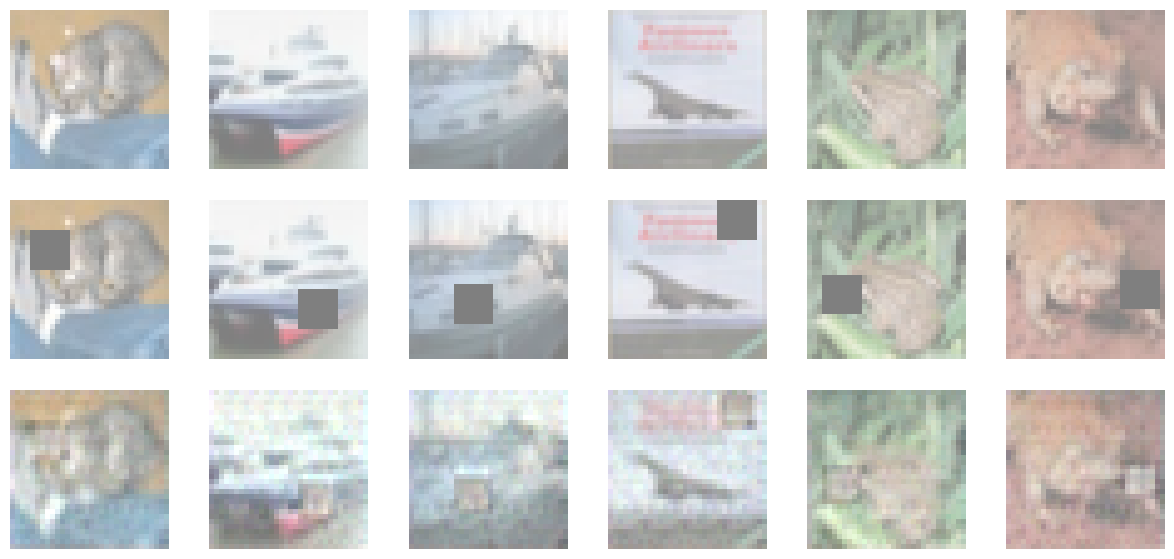

In [39]:
def test(generator, test_loader):
    generator.eval()
    recon_losses, psnrs = [], []
    
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            masked_images, mask = apply_random_mask(images.clone())
            masked_images, mask = masked_images.to(device), mask.to(device)
            
            outputs = generator(masked_images, mask)
            
            recon_loss = F.l1_loss(outputs, images).item()
            psnr_value = psnr(images.cpu().numpy(), outputs.cpu().numpy())
            
            recon_losses.append(recon_loss)
            psnrs.append(psnr_value)
    
    avg_recon_loss = np.mean(recon_losses)
    avg_psnr = np.mean(psnrs)
    
    print(f"Average Reconstruction Loss: {avg_recon_loss:.4f}\nAverage PSNR: {avg_psnr:.4f}")

def plot_sample_outputs(generator, test_loader):
    generator.eval()
    images, _ = next(iter(test_loader))
    images = images.to(device)
    masked_images, mask = apply_random_mask(images.clone())
    masked_images, mask = masked_images.to(device), mask.to(device)
    
    with torch.no_grad():
        outputs = generator(masked_images, mask)
    
    # Plotting original, masked, and inpainted images
    fig, axes = plt.subplots(3, 6, figsize=(15, 7))
    for i in range(6):
        axes[0, i].imshow(np.transpose(images[i].cpu() / 2 + 0.5, (1, 2, 0)))
        axes[1, i].imshow(np.transpose(masked_images[i].cpu() / 2 + 0.5, (1, 2, 0)))
        axes[2, i].imshow(np.transpose(outputs[i].cpu() / 2 + 0.5, (1, 2, 0)))
        for ax in axes[:, i]:
            ax.axis("off")
    plt.show()

# Run tests and display outputs
test(generator, test_loader)
plot_sample_outputs(generator, test_loader)


# 3) Context Encoder GAN

Epoch [1/50] Loss G: 7.3070, Loss D: 0.0090, Val Loss G: 0.4375
Epoch [2/50] Loss G: 9.9560, Loss D: 0.0001, Val Loss G: 0.4728
Epoch [3/50] Loss G: 11.0116, Loss D: 0.0000, Val Loss G: 0.4889
Epoch [4/50] Loss G: 11.7284, Loss D: 0.0000, Val Loss G: 0.4896
Epoch [5/50] Loss G: 12.3805, Loss D: 0.0000, Val Loss G: 0.4893
Epoch [6/50] Loss G: 12.8509, Loss D: 0.0000, Val Loss G: 0.4884
Early stopping triggered


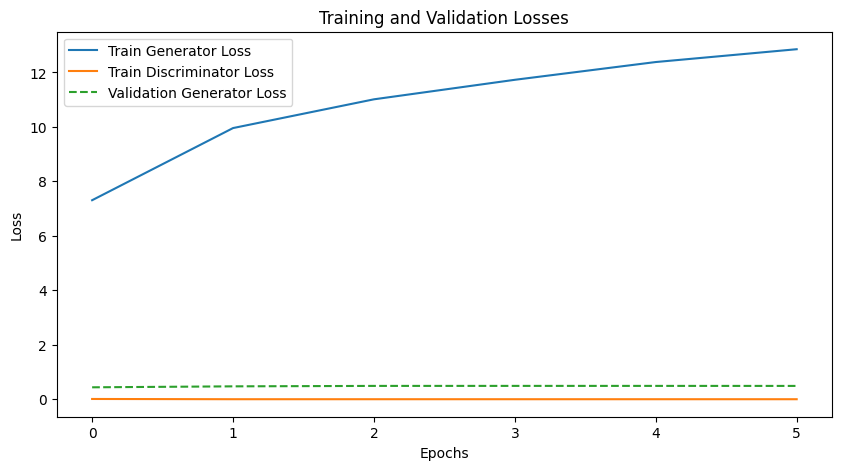

Reconstruction Loss: 0.4703
PSNR: 3.2798 dB


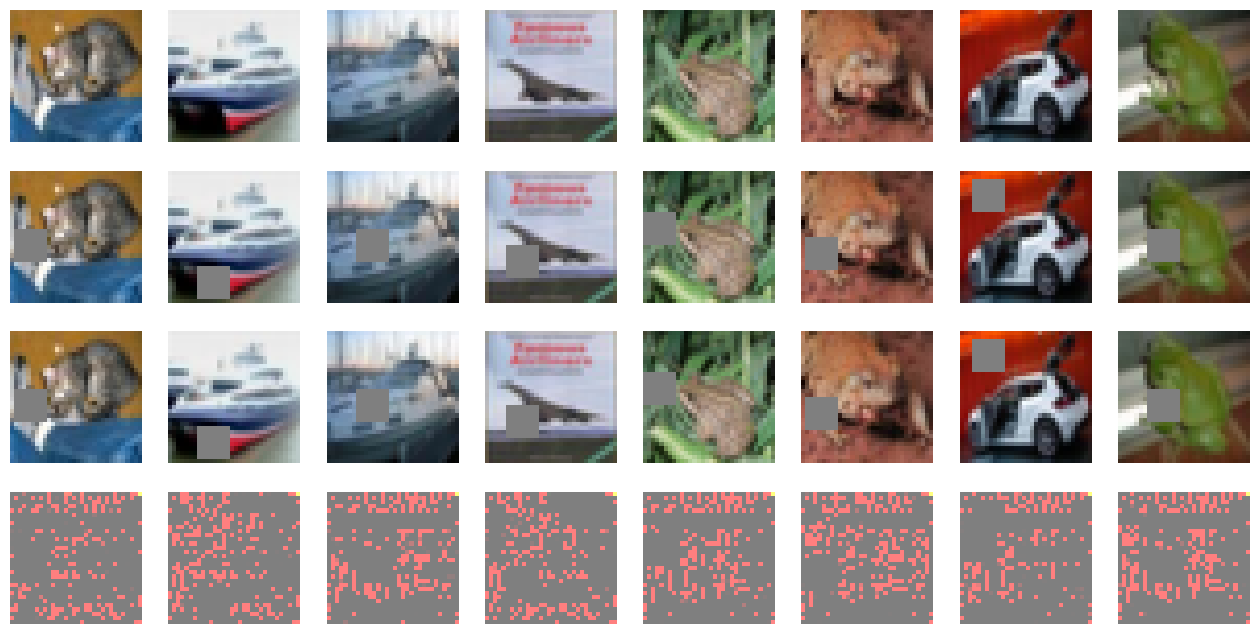

In [9]:
# Generator Model
class Generator(nn.Module):
    def __init__(self, latent_dim, img_channels):
        super(Generator, self).__init__()
        self.init_size = 8  # Initial size before upscaling
        self.latent_dim = latent_dim
        self.l1 = nn.Sequential(nn.Linear(latent_dim, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, img_channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, mask):
        out = self.l1(z)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        gen_img = self.conv_blocks(out)
        return gen_img * mask + mask  # Mask only applies to generated image


# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

def train(generator, discriminator, train_loader, val_loader, epochs, latent_dim, lr, patience):
    generator.to(device)
    discriminator.to(device)

    opt_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    scheduler_G = optim.lr_scheduler.StepLR(opt_G, step_size=10, gamma=0.5)
    scheduler_D = optim.lr_scheduler.StepLR(opt_D, step_size=10, gamma=0.5)

    criterion = nn.BCELoss()
    mse_loss = nn.MSELoss()
    min_val_loss = np.inf
    patience_counter = 0

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        train_loss_G, train_loss_D = 0.0, 0.0

        # Training Loop
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            masked_imgs, masks = apply_random_mask(imgs.clone())
            masks = masks.to(device)  # Ensure masks are on the same device

            # Train Discriminator
            opt_D.zero_grad()
            z = torch.randn(imgs.size(0), latent_dim, device=device)
            fake_imgs = generator(z, masks).detach()
            real_loss = criterion(discriminator(imgs), torch.ones(imgs.size(0), 1, device=device))
            fake_loss = criterion(discriminator(fake_imgs), torch.zeros(imgs.size(0), 1, device=device))
            loss_D = (real_loss + fake_loss) / 2
            loss_D.backward()
            opt_D.step()

            # Train Generator
            opt_G.zero_grad()
            z = torch.randn(imgs.size(0), latent_dim, device=device)
            gen_imgs = generator(z, masks)
            gen_loss = criterion(discriminator(gen_imgs), torch.ones(imgs.size(0), 1, device=device))
            gen_loss.backward()
            opt_G.step()

            train_loss_D += loss_D.item()
            train_loss_G += gen_loss.item()

        train_losses.append((train_loss_G / len(train_loader), train_loss_D / len(train_loader)))

        # Validation Loop
        generator.eval()
        val_loss_G = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                masked_imgs, masks = apply_random_mask(imgs.clone())
                masks = masks.to(device)

                z = torch.randn(imgs.size(0), latent_dim, device=device)
                gen_imgs = generator(z, masks)
                val_loss_G += mse_loss(gen_imgs, imgs).item()

        val_loss_G /= len(val_loader)
        val_losses.append(val_loss_G)

        print(f"Epoch [{epoch + 1}/{epochs}] Loss G: {train_losses[-1][0]:.4f}, Loss D: {train_losses[-1][1]:.4f}, Val Loss G: {val_loss_G:.4f}")

        # Early stopping
        if val_loss_G < min_val_loss:
            min_val_loss = val_loss_G
            patience_counter = 0
            torch.save(generator.state_dict(), "generator_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break

        scheduler_G.step()
        scheduler_D.step()

    # Plot Training and Validation Losses
    train_G_losses = [loss[0] for loss in train_losses]
    train_D_losses = [loss[1] for loss in train_losses]
    plt.figure(figsize=(10, 5))
    plt.plot(train_G_losses, label="Train Generator Loss")
    plt.plot(train_D_losses, label="Train Discriminator Loss")
    plt.plot(val_losses, label="Validation Generator Loss", linestyle="--")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Validation Losses")
    plt.show()

    return train_losses, val_losses

# Evaluation Function
def evaluate(generator, test_loader):
    generator.eval()
    psnr_total, loss_total = 0, 0
    criterion = nn.MSELoss()

    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            masked_imgs, masks = apply_random_mask(imgs)
            masked_imgs, masks = masked_imgs.to(device), masks.to(device)

            z = torch.randn(imgs.size(0), latent_dim, device=device)
            inpainted_imgs = generator(z, masks)

            loss = criterion(inpainted_imgs, imgs)
            loss_total += loss.item()

            psnr = 10 * torch.log10(1 / loss)
            psnr_total += psnr.item()

    print(f"Reconstruction Loss: {loss_total / len(test_loader):.4f}")
    print(f"PSNR: {psnr_total / len(test_loader):.4f} dB")

# Final Visualization
def visualize_samples(generator, loader):
    generator.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs.to(device)
    masked_imgs, masks = apply_random_mask(imgs.clone())
    z = torch.randn(imgs.size(0), latent_dim, device=device)
    inpainted_imgs = generator(z, masks)

    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    for i in range(8):
        axes[0, i].imshow(np.transpose(imgs[i].cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[1, i].imshow(np.transpose(masked_imgs[i].cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[2, i].imshow(np.transpose((masks[i] * imgs[i]).cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[3, i].imshow(np.transpose(inpainted_imgs[i].cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        for j in range(4):
            axes[j, i].axis("off")
    plt.show()


# Hyperparameters
latent_dim = 100
epochs = 50
lr = 0.0002
patience = 5

# Initialize models
generator = Generator(latent_dim, img_channels=3)
discriminator = Discriminator(img_channels=3)

# Train
train_losses, test_losses = train(generator, discriminator, train_loader, val_loader, epochs, latent_dim, lr, patience)

# Evaluate
evaluate(generator, test_loader)

# Visualize
visualize_samples(generator, test_loader)


### Update to Overcome Non-Converging Behaviour

Epoch [1/50] Loss G: 5.8739, Loss D: 0.1725
Epoch [2/50] Loss G: 8.0250, Loss D: 0.1636
Epoch [3/50] Loss G: 8.9779, Loss D: 0.1631
Epoch [4/50] Loss G: 9.6665, Loss D: 0.1629
Epoch [5/50] Loss G: 10.2381, Loss D: 0.1628
Epoch [6/50] Loss G: 10.7295, Loss D: 0.1627
Epoch [7/50] Loss G: 10.5608, Loss D: 0.1627
Epoch [8/50] Loss G: 11.4637, Loss D: 0.1627
Epoch [9/50] Loss G: 11.4326, Loss D: 0.1626
Epoch [10/50] Loss G: 12.1949, Loss D: 0.1626
Epoch [11/50] Loss G: 11.8978, Loss D: 0.1626
Early stopping triggered
Reconstruction Loss: 0.8721
PSNR: 0.6034 dB


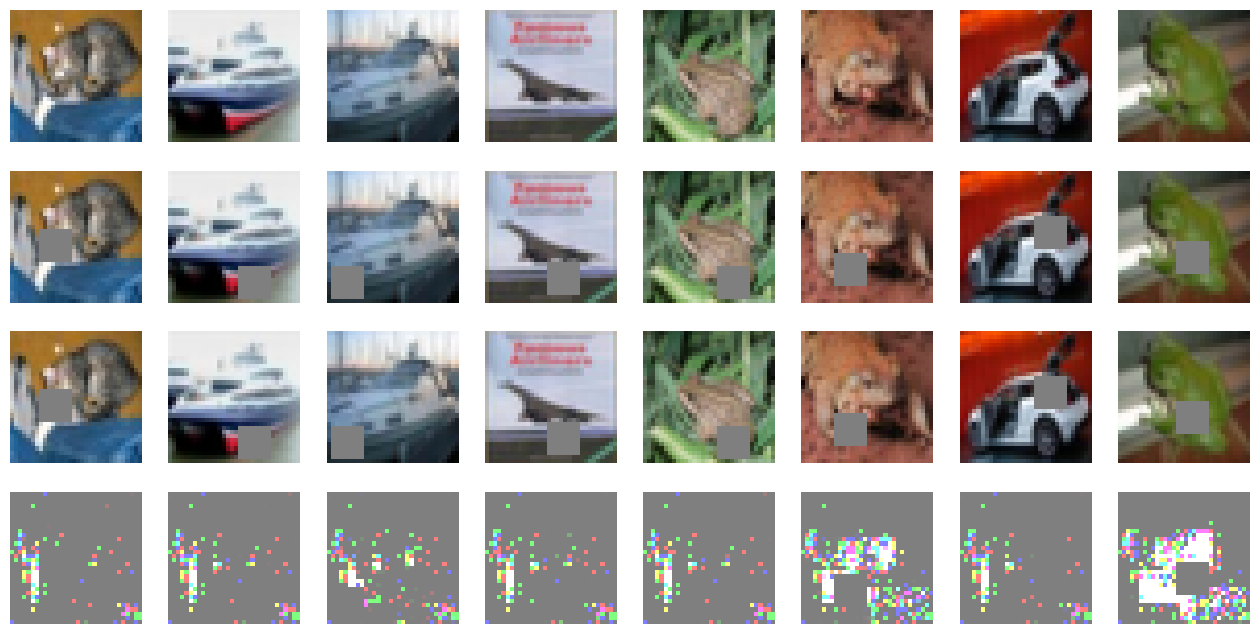

ValueError: x and y must have same first dimension, but have shapes (50,) and (11,)

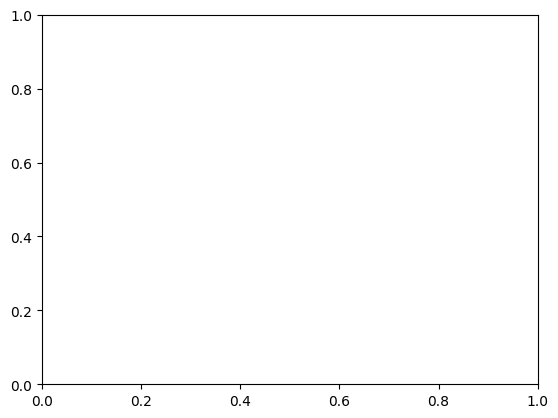

In [10]:
# Generator Model
class Generator(nn.Module):
    def __init__(self, latent_dim, img_channels):
        super(Generator, self).__init__()
        self.init_size = 8  # Initial size before upscaling
        self.latent_dim = latent_dim
        self.l1 = nn.Sequential(nn.Linear(latent_dim, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, img_channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, mask):
        out = self.l1(z)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        gen_img = self.conv_blocks(out)
        return gen_img * mask + mask  # Mask only applies to generated image


# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

# Weight Initialization
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

# Training Function
def train(generator, discriminator, dataloader, epochs, latent_dim, lr, patience):
    generator.to(device)
    discriminator.to(device)

    opt_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=lr * 0.5, betas=(0.5, 0.999))  # Reduced D learning rate
    scheduler_G = optim.lr_scheduler.StepLR(opt_G, step_size=10, gamma=0.5)
    scheduler_D = optim.lr_scheduler.StepLR(opt_D, step_size=10, gamma=0.5)

    criterion = nn.BCELoss()
    min_val_loss = np.inf
    patience_counter = 0

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        epoch_loss_G, epoch_loss_D = 0.0, 0.0

        for imgs, _ in dataloader:
            imgs = imgs.to(device)
            masked_imgs, masks = apply_random_mask(imgs.clone())
            masks = masks.to(device)  # Ensure masks are on the same device

            # Train Discriminator
            opt_D.zero_grad()
            z = torch.randn(imgs.size(0), latent_dim, device=device)
            fake_imgs = generator(z, masks).detach()
            real_loss = criterion(discriminator(imgs), torch.ones(imgs.size(0), 1, device=device) * 0.9)  # Label smoothing
            fake_loss = criterion(discriminator(fake_imgs), torch.zeros(imgs.size(0), 1, device=device))
            loss_D = (real_loss + fake_loss) / 2
            loss_D.backward()
            opt_D.step()

            # Train Generator
            opt_G.zero_grad()
            z = torch.randn(imgs.size(0), latent_dim, device=device)
            gen_imgs = generator(z, masks)
            gen_loss = criterion(discriminator(gen_imgs), torch.ones(imgs.size(0), 1, device=device))
            gen_loss.backward()
            opt_G.step()

            epoch_loss_D += loss_D.item()
            epoch_loss_G += gen_loss.item()

        train_losses.append((epoch_loss_G / len(dataloader), epoch_loss_D / len(dataloader)))
        scheduler_G.step()
        scheduler_D.step()

        print(f"Epoch [{epoch + 1}/{epochs}] Loss G: {train_losses[-1][0]:.4f}, Loss D: {train_losses[-1][1]:.4f}")

        # Early stopping
        if epoch_loss_G < min_val_loss:
            min_val_loss = epoch_loss_G
            patience_counter = 0
            torch.save(generator.state_dict(), "generator_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break

    return train_losses

# Evaluation Function
def evaluate(generator, test_loader):
    generator.eval()
    psnr_total, loss_total = 0, 0
    criterion = nn.MSELoss()

    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            masked_imgs, masks = apply_random_mask(imgs)
            masked_imgs, masks = masked_imgs.to(device), masks.to(device)

            z = torch.randn(imgs.size(0), latent_dim, device=device)
            inpainted_imgs = generator(z, masks)

            loss = criterion(inpainted_imgs, imgs)
            loss_total += loss.item()

            psnr = 10 * torch.log10(1 / loss)
            psnr_total += psnr.item()

    print(f"Reconstruction Loss: {loss_total / len(test_loader):.4f}")
    print(f"PSNR: {psnr_total / len(test_loader):.4f} dB")

# Final Visualization
def visualize_samples(generator, loader):
    generator.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs.to(device)
    masked_imgs, masks = apply_random_mask(imgs.clone())
    z = torch.randn(imgs.size(0), latent_dim, device=device)
    inpainted_imgs = generator(z, masks)

    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    for i in range(8):
        axes[0, i].imshow(np.transpose(imgs[i].cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[1, i].imshow(np.transpose(masked_imgs[i].cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[2, i].imshow(np.transpose((masks[i] * imgs[i]).cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[3, i].imshow(np.transpose(inpainted_imgs[i].cpu().detach().numpy() / 2 + 0.5, (1, 2, 0)))
        for j in range(4):
            axes[j, i].axis("off")
    plt.show()


# Hyperparameters
latent_dim = 100
epochs = 50
lr = 0.0002
patience = 10  # Increased patience

# Initialize models
generator = Generator(latent_dim, img_channels=3)
discriminator = Discriminator(img_channels=3)

# Apply weight initialization
generator.apply(init_weights)
discriminator.apply(init_weights)

# Train
train_losses = train(generator, discriminator, train_loader, epochs, latent_dim, lr, patience)

# Evaluate
evaluate(generator, test_loader)

# Visualize
visualize_samples(generator, test_loader)

# Plot train and test losses
train_loss_G, train_loss_D = zip(*train_losses)
plt.plot(range(1, epochs + 1), train_loss_G, label='Generator Loss')
plt.plot(range(1, epochs + 1), train_loss_D, label='Discriminator Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Updated but still it didn't work. Trying some other models now.

# 4) Deep GAN 
### Convolution Based

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
img_channels = 3

# Generator with BatchNorm and more complexity
class ComplexGenerator(nn.Module):
    def __init__(self, latent_dim, img_channels):
        super(ComplexGenerator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, img_channels * 32 * 32),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(out.size(0), img_channels, 32, 32)

# Discriminator with Convolutional Layers and BatchNorm
class ComplexDiscriminator(nn.Module):
    def __init__(self, img_channels):
        super(ComplexDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

Epoch [1/50] - Generator Loss: 1.1578, Discriminator Loss: 1.1686, Validation Loss: 0.5743
Epoch [2/50] - Generator Loss: 1.6550, Discriminator Loss: 0.8984, Validation Loss: 0.6174
Epoch [3/50] - Generator Loss: 3.1145, Discriminator Loss: 0.4309, Validation Loss: 0.5962
Epoch [4/50] - Generator Loss: 3.9304, Discriminator Loss: 0.2916, Validation Loss: 0.5777
Epoch [5/50] - Generator Loss: 4.5387, Discriminator Loss: 0.2112, Validation Loss: 0.5663
Epoch [6/50] - Generator Loss: 5.3280, Discriminator Loss: 0.1336, Validation Loss: 0.5366
Epoch [7/50] - Generator Loss: 5.5206, Discriminator Loss: 0.1245, Validation Loss: 0.5721
Epoch [8/50] - Generator Loss: 5.8520, Discriminator Loss: 0.1043, Validation Loss: 0.5493
Epoch [9/50] - Generator Loss: 6.1763, Discriminator Loss: 0.0921, Validation Loss: 0.5389
Epoch [10/50] - Generator Loss: 6.2319, Discriminator Loss: 0.0900, Validation Loss: 0.5427
Epoch [11/50] - Generator Loss: 5.3704, Discriminator Loss: 0.0641, Validation Loss: 0.53

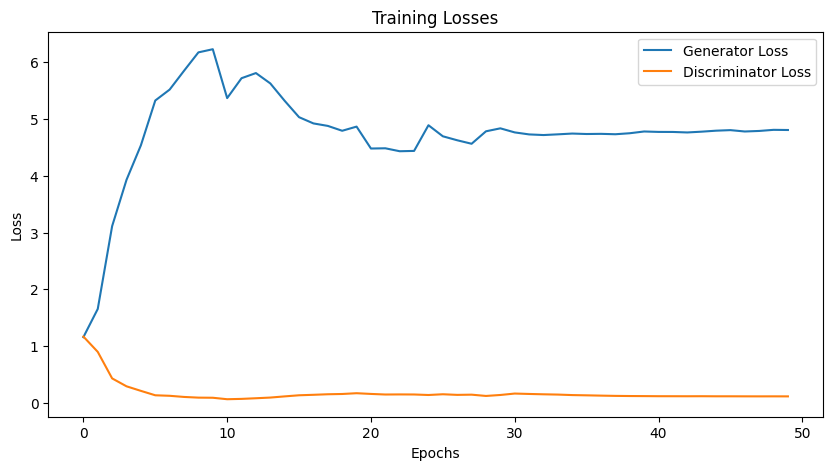

In [4]:


# Initialize models
generator = ComplexGenerator(latent_dim, img_channels).to(device)
discriminator = ComplexDiscriminator(img_channels).to(device)

# Loss functions and optimizers
adversarial_loss_fn = nn.BCELoss()
gen_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training parameters
num_epochs = 50
train_g_losses = []
train_d_losses = []

# Add learning rate schedulers
scheduler_gen = optim.lr_scheduler.StepLR(gen_optimizer, step_size=10, gamma=0.1)
scheduler_disc = optim.lr_scheduler.StepLR(disc_optimizer, step_size=10, gamma=0.1)

# Early stopping parameters
patience = 5
min_delta = 0.001
best_val_loss = float("inf")
no_improvement_epochs = 0

# Training loop
for epoch in range(num_epochs):
    generator.train()
    discriminator.train()

    g_running_loss = 0.0
    d_running_loss = 0.0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Generate noise and fake images
        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(noise)

        # Labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Train Discriminator (1 update)
        disc_optimizer.zero_grad()
        real_loss = adversarial_loss_fn(discriminator(real_images), real_labels)
        fake_loss = adversarial_loss_fn(discriminator(fake_images.detach()), fake_labels)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        disc_optimizer.step()
        
        # Train Generator 
        
        gen_optimizer.zero_grad()
        fake_outputs = discriminator(fake_images)
        g_loss = adversarial_loss_fn(fake_outputs, real_labels)
        g_loss.backward()
        gen_optimizer.step()

        g_running_loss += g_loss.item()
        d_running_loss += d_loss.item()

    # Average losses for the epoch
    avg_g_loss = g_running_loss / len(train_loader)
    avg_d_loss = d_running_loss / len(train_loader)
    train_g_losses.append(avg_g_loss)
    train_d_losses.append(avg_d_loss)

    # Learning rate scheduling
    scheduler_gen.step()
    scheduler_disc.step()

    # Validation phase (using generator reconstruction loss)
    generator.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for val_images, _ in test_loader:
            val_images = val_images.to(device)
            noise = torch.randn(val_images.size(0), latent_dim, device=device)
            generated_images = generator(noise)
            val_loss = F.l1_loss(generated_images, val_images)
            val_running_loss += val_loss.item()

    avg_val_loss = val_running_loss / len(test_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Generator Loss: {avg_g_loss:.4f}, Discriminator Loss: {avg_d_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

#     # Early stopping check
#     if avg_val_loss < best_val_loss - min_delta:
#         best_val_loss = avg_val_loss
#         no_improvement_epochs = 0
#     else:
#         no_improvement_epochs += 1

#     if no_improvement_epochs >= patience:
#         print("Early stopping triggered.")
#         break

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_g_losses, label='Generator Loss')
plt.plot(train_d_losses, label='Discriminator Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Losses")
plt.show()

In [5]:
# Save models
model_dir = './saved_models'
os.makedirs(model_dir, exist_ok=True)

def save_model(generator, discriminator, gen_optimizer, disc_optimizer, epoch, filename="simple_gan.pth"):
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'gen_optimizer_state_dict': gen_optimizer.state_dict(),
        'disc_optimizer_state_dict': disc_optimizer.state_dict(),
    }, os.path.join(model_dir, filename))
    print("Model saved successfully.")

save_model(generator, discriminator, gen_optimizer, disc_optimizer, num_epochs)

# Load models
def load_model(generator, discriminator, gen_optimizer, disc_optimizer, filename="simple_gan.pth"):
    checkpoint = torch.load(os.path.join(model_dir, filename), map_location=device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    gen_optimizer.load_state_dict(checkpoint['gen_optimizer_state_dict'])
    disc_optimizer.load_state_dict(checkpoint['disc_optimizer_state_dict'])
    epoch = checkpoint['epoch']
    print(f"Model loaded successfully. Resuming from epoch {epoch}.")
    return epoch

start_epoch = load_model(generator, discriminator, gen_optimizer, disc_optimizer)

Model saved successfully.
Model loaded successfully. Resuming from epoch 50.


/tmp/ipykernel_30/2645872204.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(model_dir, filename), map_location=device)


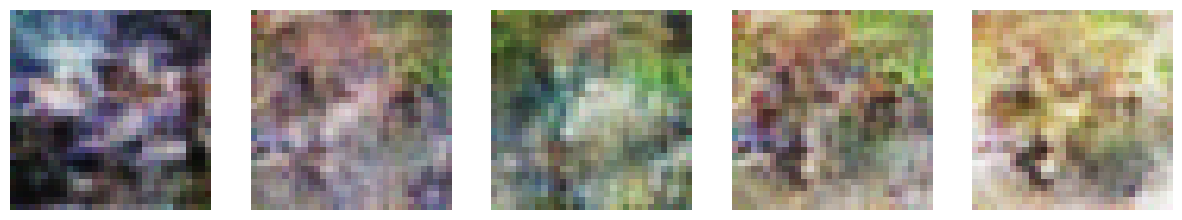

In [6]:
# Visualize generated results
def visualize_results(generator, num_images=5):
    generator.eval()
    noise = torch.randn(num_images, latent_dim, device=device)
    with torch.no_grad():
        generated_images = generator(noise).cpu()
    generated_images = (generated_images + 1) / 2  # Denormalize to [0, 1]

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        axes[i].imshow(np.transpose(generated_images[i].numpy(), (1, 2, 0)))
        axes[i].axis("off")
    plt.show()

visualize_results(generator)

In [7]:
def average_reconstruction_loss(generator, test_loader, device):
    generator.eval()
    total_loss = 0.0
    with torch.no_grad():
        for val_images, _ in test_loader:
            val_images = val_images.to(device)
            noise = torch.randn(val_images.size(0), latent_dim, device=device)
            generated_images = generator(noise)
            # Compute L1 loss between generated and real images
            loss = F.l1_loss(generated_images, val_images)
            total_loss += loss.item()
    
    avg_loss = total_loss / len(test_loader)
    return avg_loss
avg_loss = average_reconstruction_loss(generator, test_loader, device)
print(f"Average Reconstruction Loss: {avg_loss:.4f}")

Average Reconstruction Loss: 0.5358


In [8]:
def psnr_score(generated_images, real_images):
    # Ensure the images are in the range [0, 1]
    generated_images = (generated_images + 1) / 2  # Denormalize if the images are in the range [-1, 1]
    real_images = (real_images + 1) / 2  # Denormalize if the images are in the range [-1, 1]

    # Convert to numpy for easier MSE calculation
    generated_images = generated_images.cpu().numpy()
    real_images = real_images.cpu().numpy()

    # Compute MSE (Mean Squared Error)
    mse = np.mean((generated_images - real_images) ** 2)
    
    if mse == 0:
        return 100  # PSNR is infinite if MSE is zero (perfect reconstruction)
    
    # Compute PSNR
    psnr = 10 * np.log10(1.0 / mse)
    return psnr

In [9]:
psnr = psnr_score(generated_images, val_images)
print(f"PSNR Score: {psnr:.2f} dB")

PSNR Score: 9.98 dB


# 5) Hybrid Autoencoder-GAN

In [2]:
class AutoencoderGenerator(nn.Module):
    def __init__(self, img_channels):
        super(AutoencoderGenerator, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        bottleneck = self.bottleneck(encoded)
        decoded = self.decoder(bottleneck)
        return decoded

class SimpleDiscriminator(nn.Module):
    def __init__(self, img_channels):
        super(SimpleDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels * 32 * 32, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)


Epoch 26/50 - Validation: 100%|██████████| 157/157 [00:01<00:00, 88.78it/s] 


Early stopping triggered.


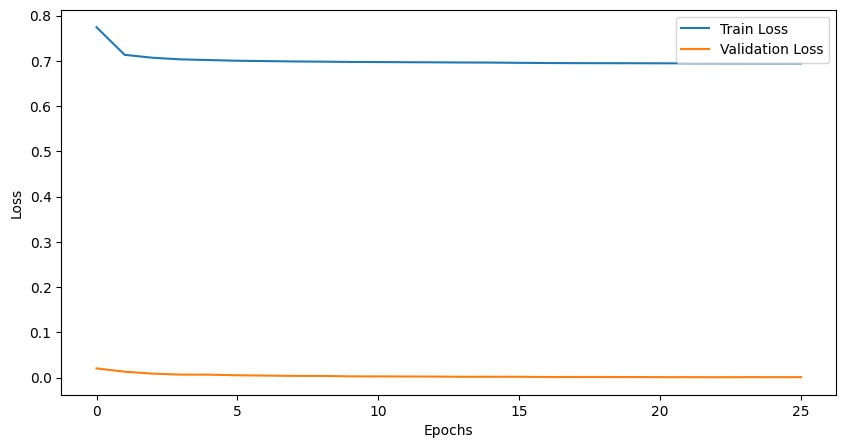

In [7]:
# Hyperparameters
img_channels = 3
batch_size = 64
lr = 0.0002
num_epochs = 50
patience = 3

# Models
generator = AutoencoderGenerator(img_channels).to('cuda')
discriminator = SimpleDiscriminator(img_channels).to('cuda')

# Losses
criterion_g = nn.MSELoss()  # For the generator
criterion_d = nn.BCELoss()  # For the discriminator

# Optimizers
optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# LR Scheduler
scheduler_g = optim.lr_scheduler.ReduceLROnPlateau(optimizer_g, mode='min', patience=3, factor=0.5, verbose=True)
scheduler_d = optim.lr_scheduler.ReduceLROnPlateau(optimizer_d, mode='min', patience=3, factor=0.5, verbose=True)


# Early stopping variables
best_val_loss = float('inf')
early_stop_counter = 0

# Tracking losses
train_losses, val_losses = [], []

# Training loop
for epoch in range(num_epochs):
    generator.train()
    discriminator.train()
    train_loss = 0
    val_loss = 0
    
    # Training
    for real_images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        real_images = real_images.to('cuda')

        # Train Discriminator
        optimizer_d.zero_grad()
        real_labels = torch.ones(real_images.size(0), 1).to('cuda')
        fake_labels = torch.zeros(real_images.size(0), 1).to('cuda')

        outputs_real = discriminator(real_images)
        d_real_loss = criterion_d(outputs_real, real_labels)

        fake_images = generator(real_images).detach()
        outputs_fake = discriminator(fake_images)
        d_fake_loss = criterion_d(outputs_fake, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_d.step()

        # Train Generator
        optimizer_g.zero_grad()
        fake_images = generator(real_images)
        outputs = discriminator(fake_images)
        g_loss = criterion_g(fake_images, real_images) + criterion_d(outputs, real_labels)

        g_loss.backward()
        optimizer_g.step()

        train_loss += g_loss.item()

    train_losses.append(train_loss / len(train_loader))

    # Validation
    generator.eval()
    with torch.no_grad():
        for val_images, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            val_images = val_images.to('cuda')
            fake_images = generator(val_images)
            val_loss += criterion_g(fake_images, val_images).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler_g.step(val_loss)
    scheduler_d.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(generator.state_dict(), "best_generator.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [8]:
# Test accuracy
generator.load_state_dict(torch.load("best_generator.pth"))
generator.eval()

test_loss = 0
with torch.no_grad():
    for test_images, _ in test_loader:
        test_images = test_images.to('cuda')
        fake_images = generator(test_images)
        test_loss += criterion_g(fake_images, test_images).item()

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

/tmp/ipykernel_30/382851470.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load("best_generator.pth"))


Test Loss: 0.0008


0.9375


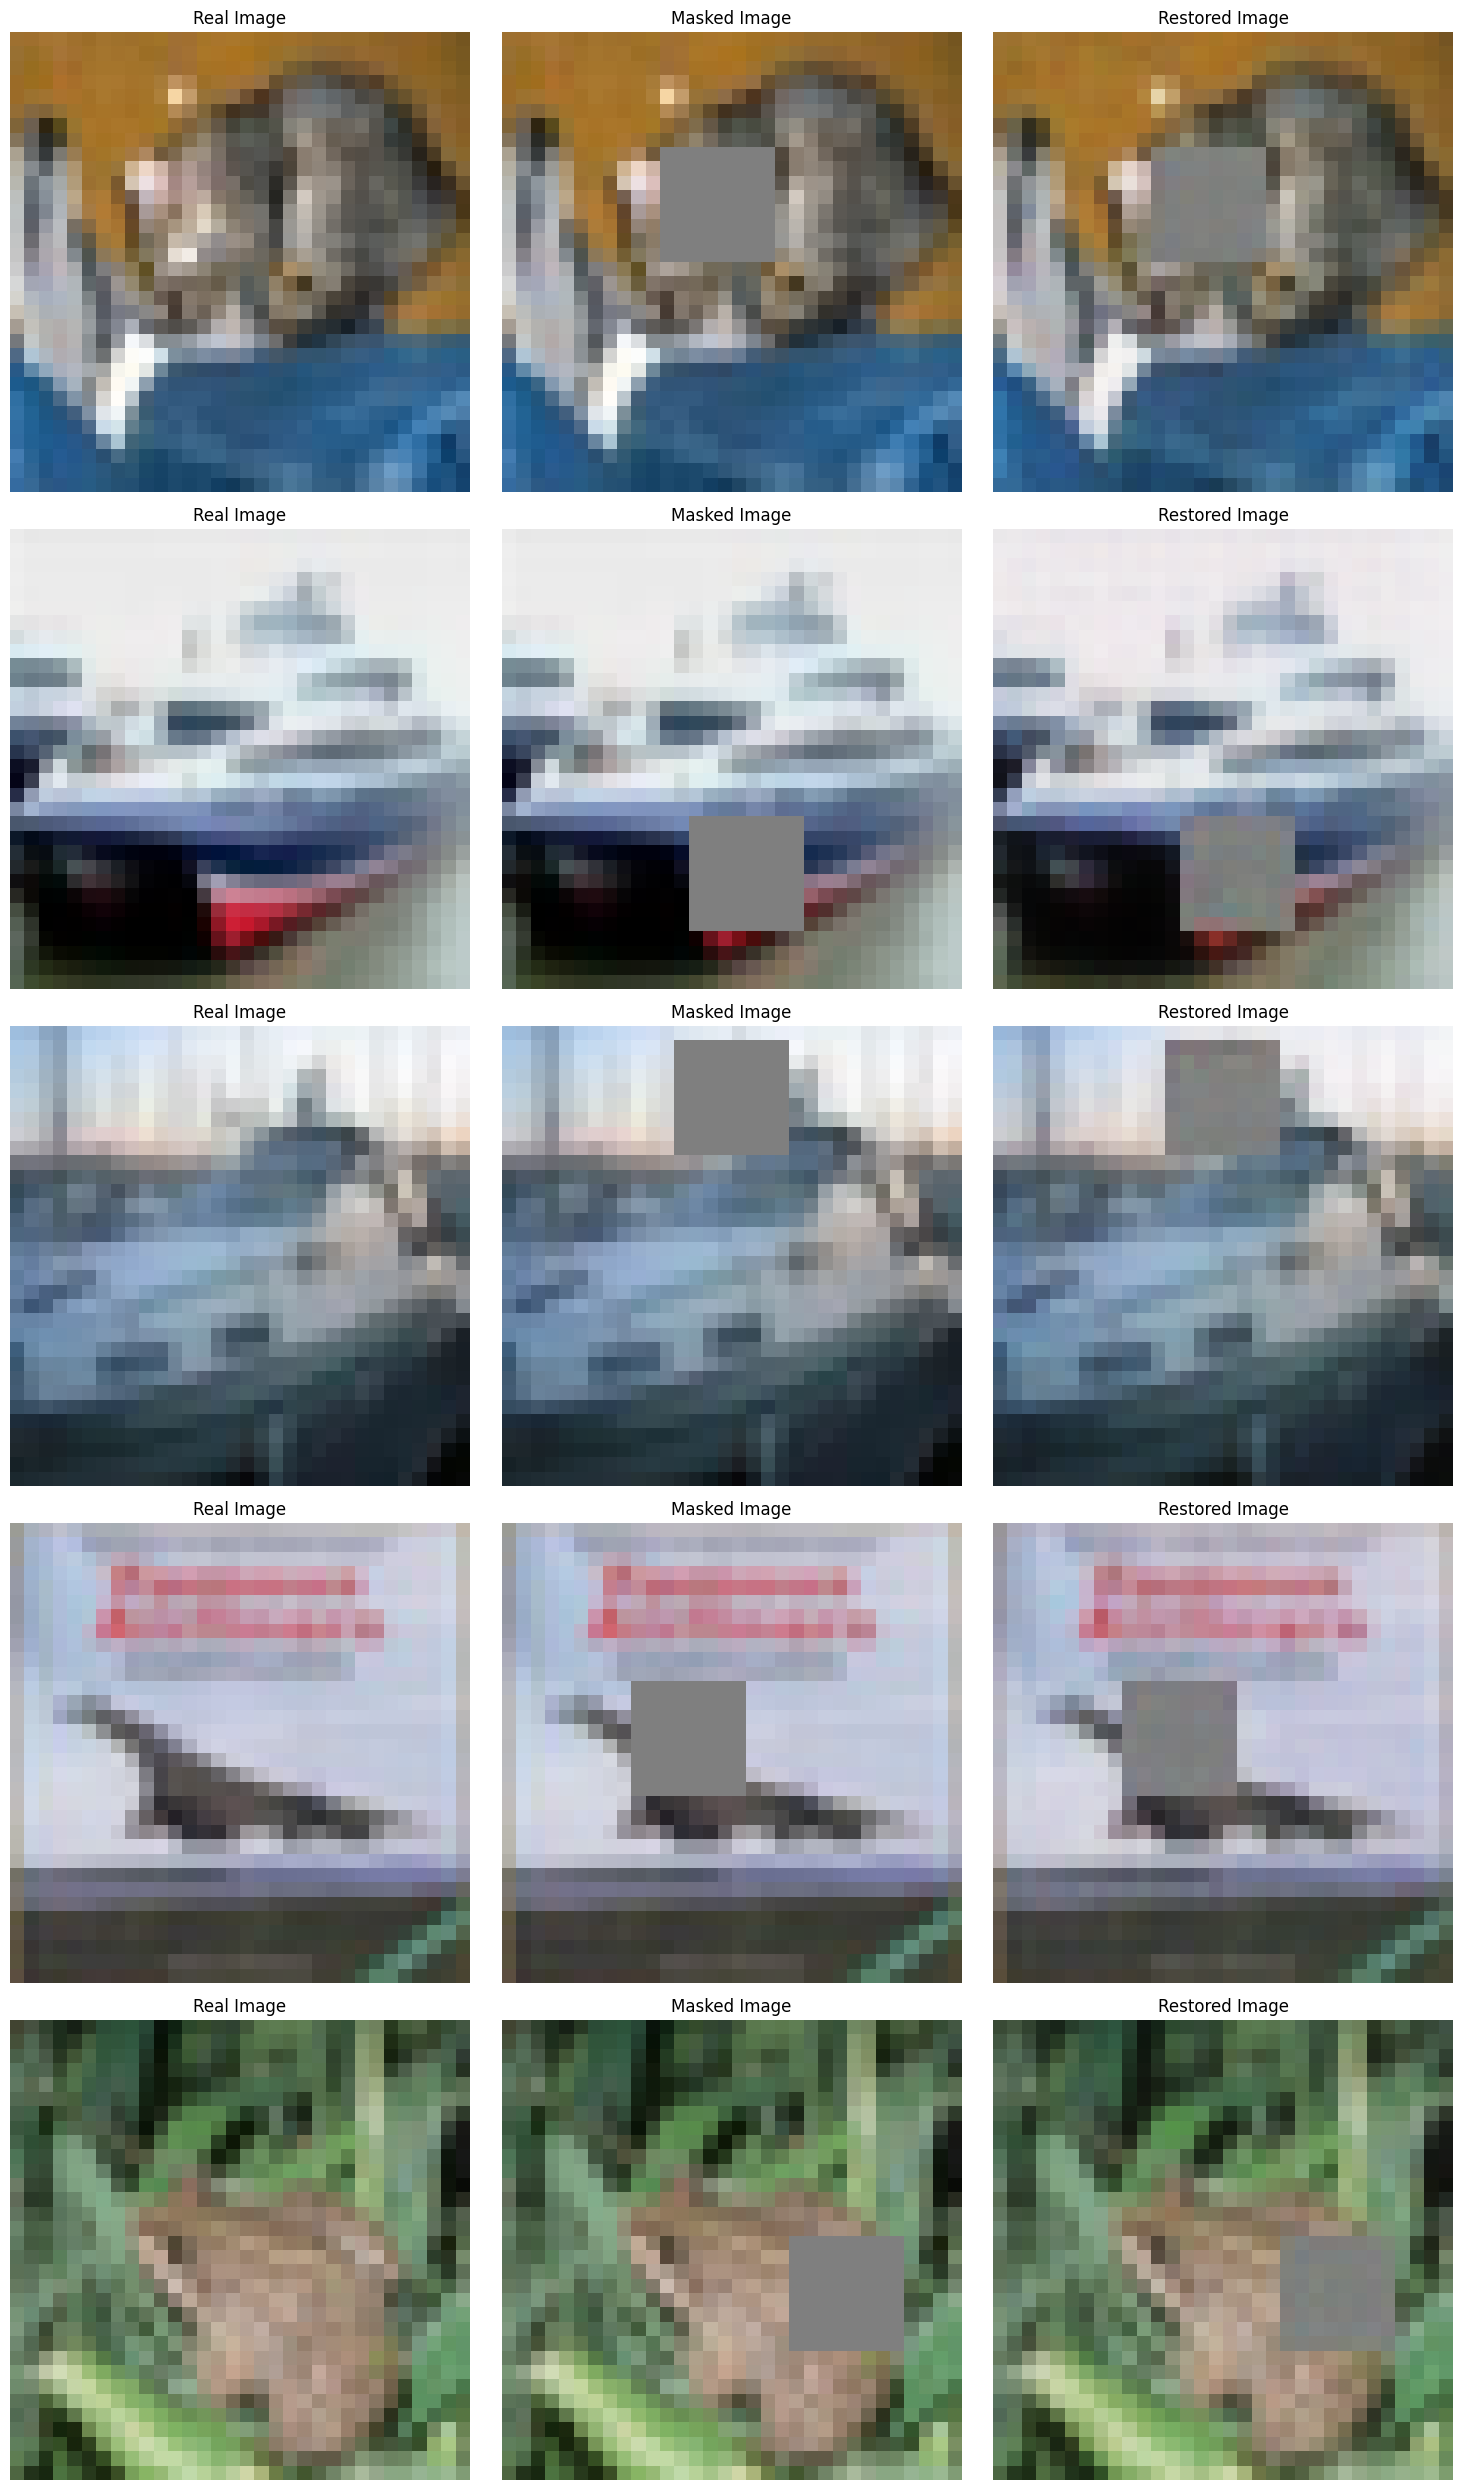

In [9]:
def visualize_inpainting_results(generator, dataloader, mask_function, num_images=5, device='cuda'):
    generator.eval()  # Set the generator to evaluation mode
    images_shown = 0

    with torch.no_grad():
        for real_images, _ in dataloader:
            real_images = real_images.to(device)

            # Make a copy of real_images to keep them intact
            original_images = real_images.clone()

            # Generate masked images using the mask function (applied to the copy of real_images)
            masked_images, mask = mask_function(real_images)  # masked_images should have missing areas

            # Ensure that the mask is applied correctly (you can inspect `mask` if needed)
            print(mask.mean().item())  # Check if the mask is being applied properly (should be < 1)

            # Generate restored images using the generator
            restored_images = generator(masked_images)

            # Denormalize images for visualization (from [-1, 1] to [0, 1])
            original_images = (original_images * 0.5 + 0.5).clamp(0, 1)
            masked_images = (masked_images * 0.5 + 0.5).clamp(0, 1)
            restored_images = (restored_images * 0.5 + 0.5).clamp(0, 1)

            # Plot real, masked, and restored images
            fig, axes = plt.subplots(num_images, 3, figsize=(15, num_images * 5))
            for i in range(num_images):
                if images_shown >= len(real_images):
                    break

                # Plot real image (original)
                axes[i, 0].imshow(original_images[i].permute(1, 2, 0).cpu().numpy())
                axes[i, 0].set_title("Real Image")
                axes[i, 0].axis("off")

                # Plot masked image
                axes[i, 1].imshow(masked_images[i].permute(1, 2, 0).cpu().numpy())
                axes[i, 1].set_title("Masked Image")
                axes[i, 1].axis("off")

                # Plot restored image
                axes[i, 2].imshow(restored_images[i].permute(1, 2, 0).cpu().numpy())
                axes[i, 2].set_title("Restored Image")
                axes[i, 2].axis("off")

                images_shown += 1

            plt.tight_layout()
            plt.show()

            if images_shown >= num_images:
                break

# Assuming the generator and test_loader are already defined
visualize_inpainting_results(generator, test_loader, mask_function=apply_random_mask, num_images=5)


### Update to deal with non converging behavior

Epoch 1/25 - Validation: 100%|██████████| 157/157 [00:01<00:00, 89.06it/s]


Epoch 1: New best model saved with validation loss: 0.0673
Epoch [1/25] - Train Loss: 5174.9833, Val Loss: 0.0673


Epoch 2/25 - Validation: 100%|██████████| 157/157 [00:01<00:00, 94.33it/s] 


Epoch 2: New best model saved with validation loss: 0.0563
Epoch [2/25] - Train Loss: 1965.2656, Val Loss: 0.0563


Epoch 3/25 - Validation: 100%|██████████| 157/157 [00:01<00:00, 92.55it/s] 


...

Epoch 23: New best model saved with validation loss: 0.0250
Epoch [23/25] - Train Loss: -1064.7287, Val Loss: 0.0250


Epoch 24/25 - Validation: 100%|██████████| 157/157 [00:01<00:00, 90.24it/s]


Epoch [24/25] - Train Loss: -947.5536, Val Loss: 0.0254


Epoch 25/25 - Validation: 100%|██████████| 157/157 [00:01<00:00, 88.57it/s]


Epoch [25/25] - Train Loss: -1175.9499, Val Loss: 0.0253


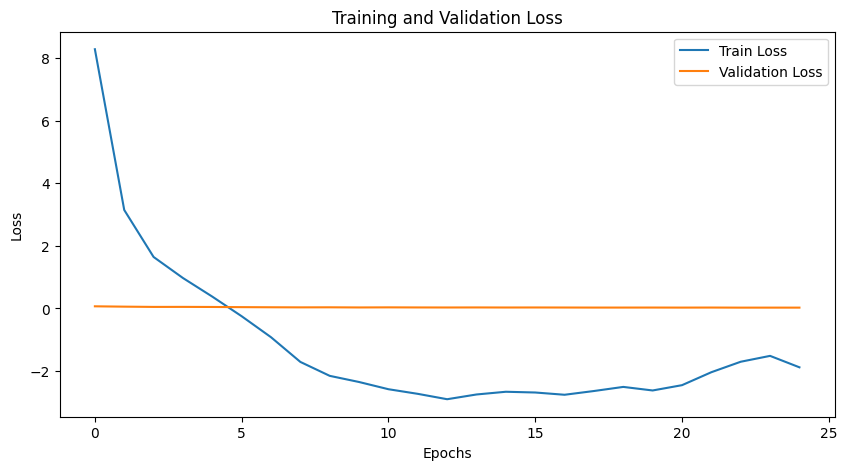

In [10]:
# Hyperparameters
img_channels = 3
batch_size = 64
lr_g = 0.0002
lr_d = 0.0001  # Lower learning rate for discriminator
num_epochs = 25
patience = 3
lambda_recon = 100  # Weight for reconstruction loss

# Generator
class AutoencoderGenerator(nn.Module):
    def __init__(self, img_channels):
        super(AutoencoderGenerator, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
        )
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        bottleneck = self.bottleneck(encoded)
        decoded = self.decoder(bottleneck)
        return decoded

# Discriminator
class PatchGANDiscriminator(nn.Module):
    def __init__(self, img_channels):
        super(PatchGANDiscriminator, self).__init__()
        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=1)),
        )

    def forward(self, img):
        return self.model(img)

# Initialize models
generator = AutoencoderGenerator(img_channels).cuda()
discriminator = PatchGANDiscriminator(img_channels).cuda()

# Loss functions
criterion_recon = nn.L1Loss()  # MAE for sharper reconstructions
criterion_adv = lambda real, fake: -torch.mean(real) + torch.mean(fake)  # WGAN loss

# Optimizers
optimizer_g = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
# Learning rate schedulers
scheduler_g = optim.lr_scheduler.ReduceLROnPlateau(optimizer_g, mode="min", patience=3, factor=0.5, verbose=True)
scheduler_d = optim.lr_scheduler.ReduceLROnPlateau(optimizer_d, mode="min", patience=3, factor=0.5, verbose=True)

# Early stopping variables
best_val_loss = float("inf")
early_stop_counter = 0

# Tracking losses
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    generator.train()
    discriminator.train()
    train_loss = 0
    val_loss = 0
    
    # Training
    for real_images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        real_images = real_images.cuda()

        # Instance noise
        noise = torch.randn_like(real_images) * 0.05
        real_images_noisy = real_images + noise

        # Train Discriminator
        optimizer_d.zero_grad()
        real_preds = discriminator(real_images_noisy)
        fake_images = generator(real_images)
        fake_preds = discriminator(fake_images.detach())

        d_loss = criterion_adv(real_preds, fake_preds)
        d_loss.backward()
        optimizer_d.step()

        # Train Generator
        optimizer_g.zero_grad()
        fake_preds = discriminator(fake_images)
        g_loss = lambda_recon * criterion_recon(fake_images, real_images) - torch.mean(fake_preds)
        g_loss.backward()
        optimizer_g.step()

        train_loss += g_loss.item()

    train_losses.append(train_loss / len(train_loader))

    # Validation
    generator.eval()
    with torch.no_grad():
        for val_images, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            val_images = val_images.cuda()
            fake_images = generator(val_images)
            val_loss += criterion_recon(fake_images, val_images).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler_g.step(val_loss)
    scheduler_d.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(generator.state_dict(), "best_generator.pth")
        print(f"Epoch {epoch+1}: New best model saved with validation loss: {val_loss:.4f}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Plotting losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

0.9375


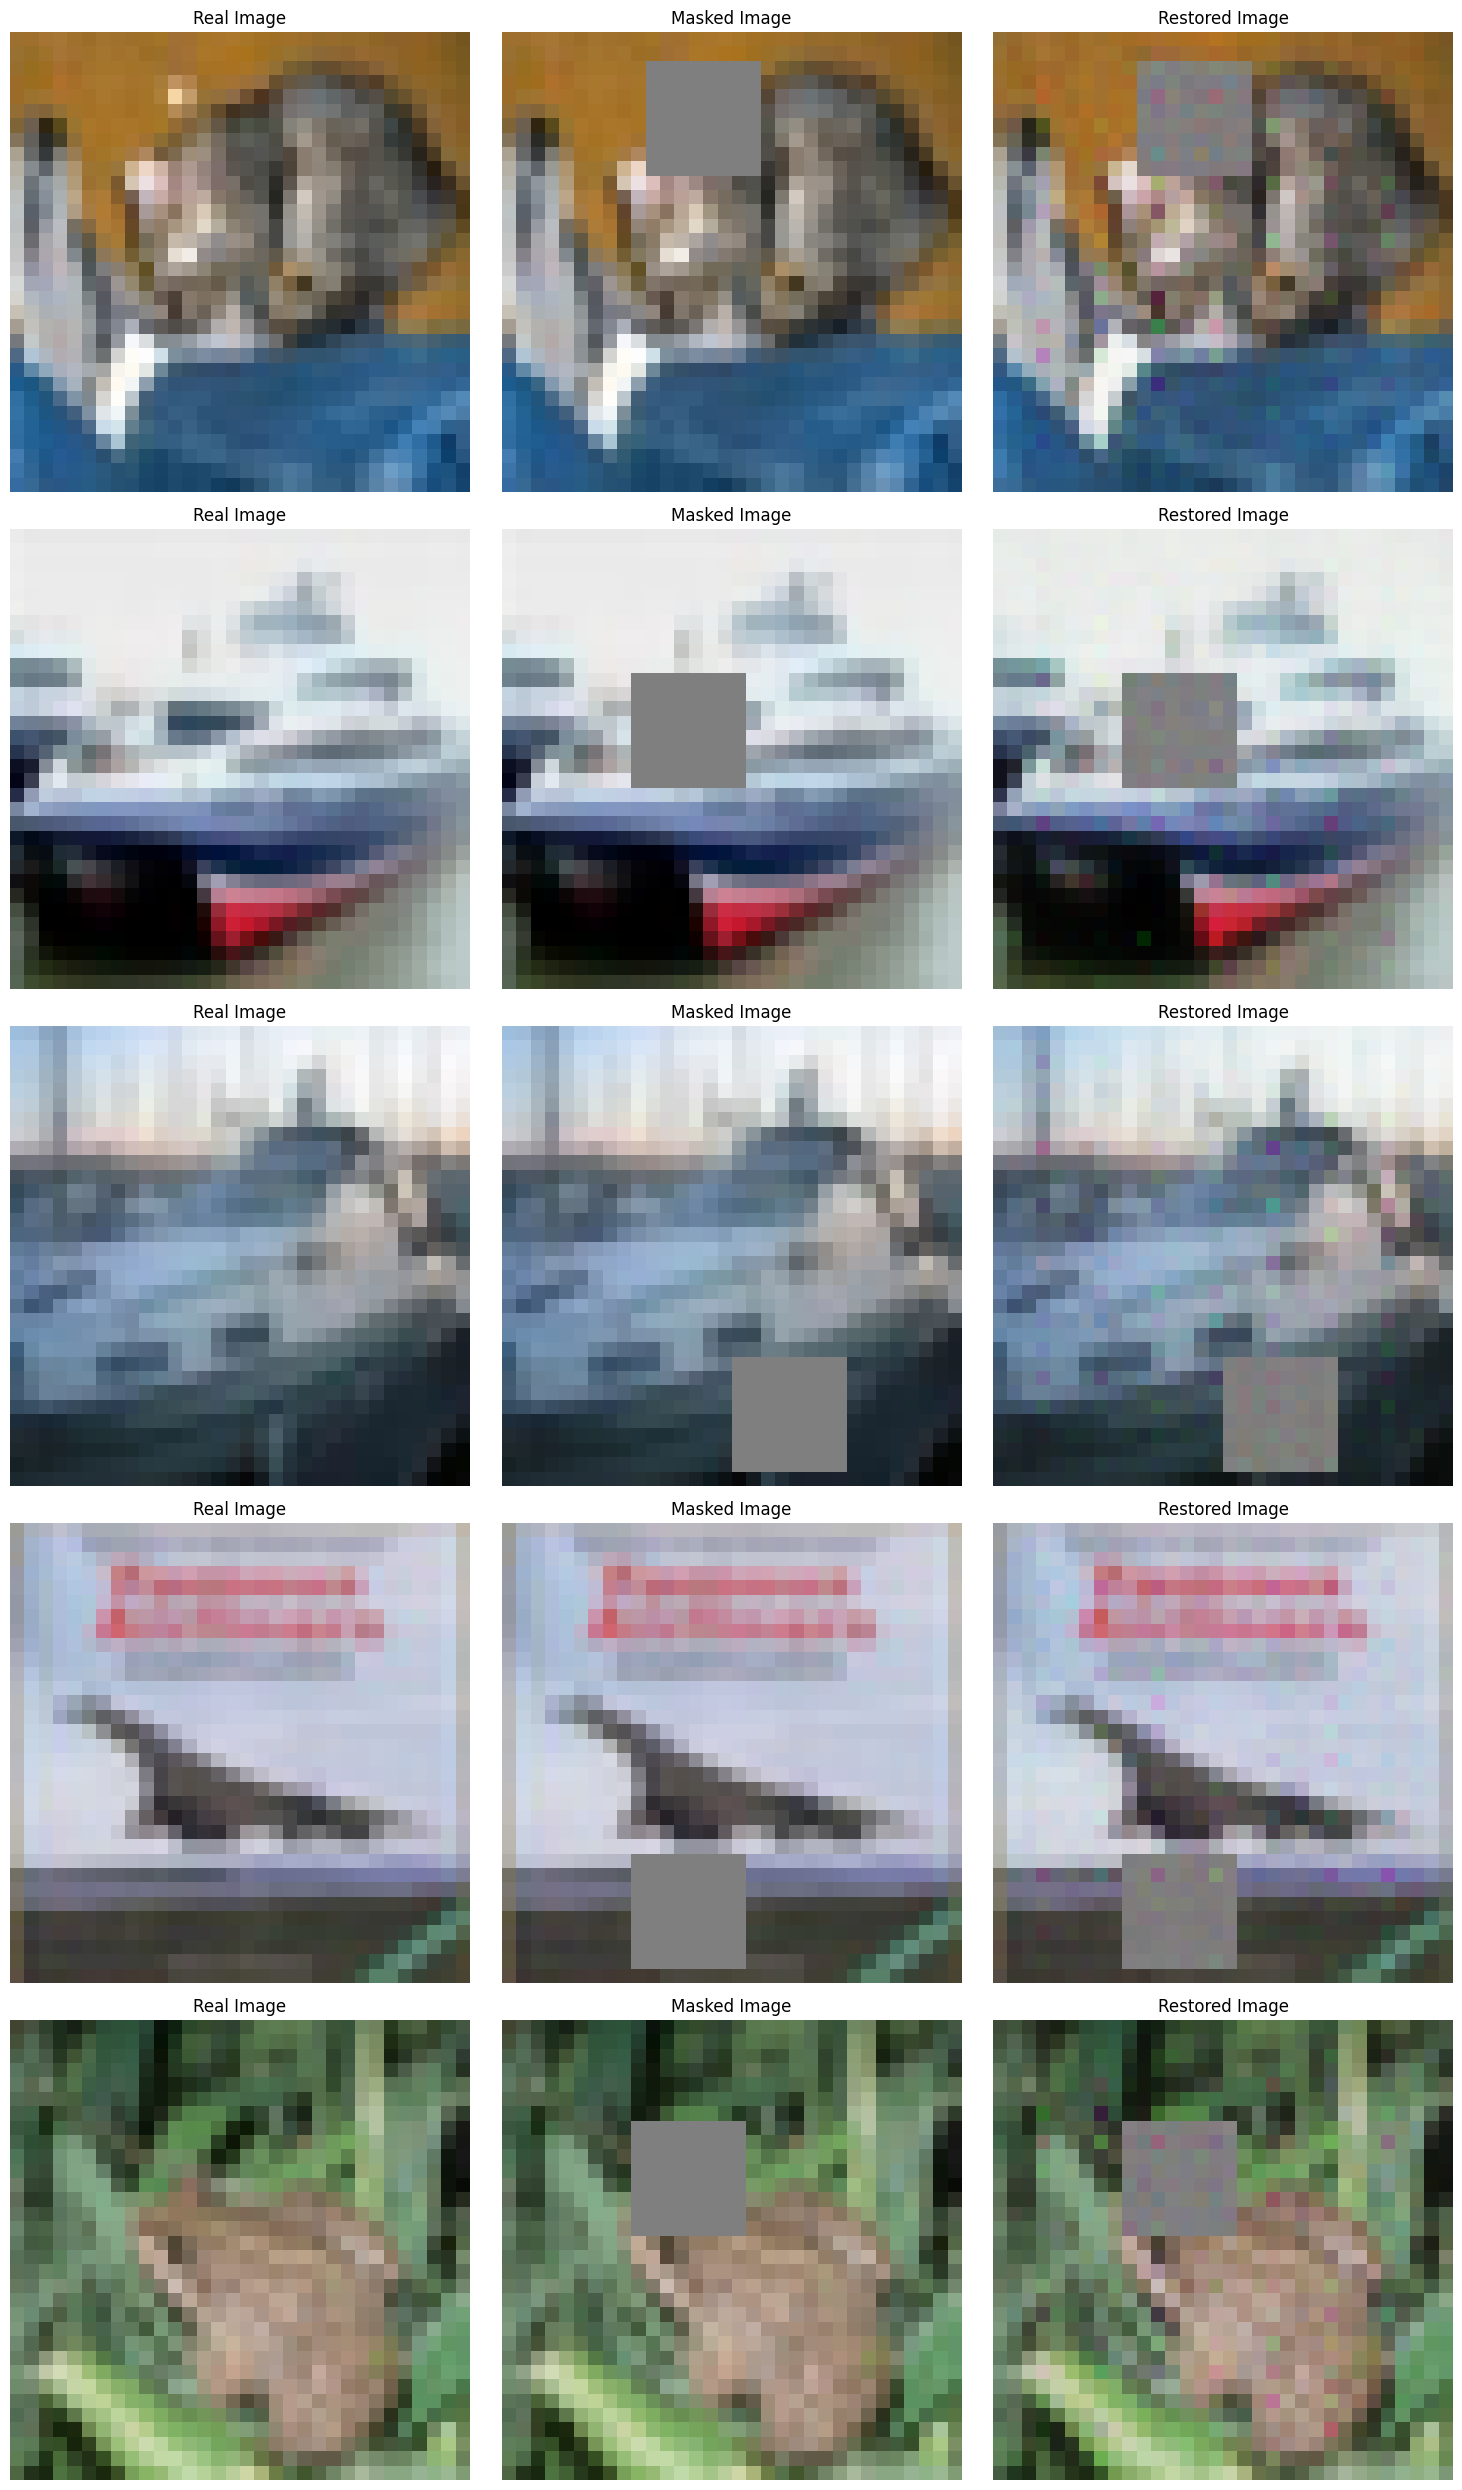

In [11]:
def visualize_inpainting_results(generator, dataloader, mask_function, num_images=5, device='cuda'):
    generator.eval()  # Set the generator to evaluation mode
    images_shown = 0

    with torch.no_grad():
        for real_images, _ in dataloader:
            real_images = real_images.to(device)

            # Make a copy of real_images to keep them intact
            original_images = real_images.clone()

            # Generate masked images using the mask function (applied to the copy of real_images)
            masked_images, mask = mask_function(real_images)  # masked_images should have missing areas

            # Ensure that the mask is applied correctly (you can inspect `mask` if needed)
            print(mask.mean().item())  # Check if the mask is being applied properly (should be < 1)

            # Generate restored images using the generator
            restored_images = generator(masked_images)

            # Denormalize images for visualization (from [-1, 1] to [0, 1])
            original_images = (original_images * 0.5 + 0.5).clamp(0, 1)
            masked_images = (masked_images * 0.5 + 0.5).clamp(0, 1)
            restored_images = (restored_images * 0.5 + 0.5).clamp(0, 1)

            # Plot real, masked, and restored images
            fig, axes = plt.subplots(num_images, 3, figsize=(15, num_images * 5))
            for i in range(num_images):
                if images_shown >= len(real_images):
                    break

                # Plot real image (original)
                axes[i, 0].imshow(original_images[i].permute(1, 2, 0).cpu().numpy())
                axes[i, 0].set_title("Real Image")
                axes[i, 0].axis("off")

                # Plot masked image
                axes[i, 1].imshow(masked_images[i].permute(1, 2, 0).cpu().numpy())
                axes[i, 1].set_title("Masked Image")
                axes[i, 1].axis("off")

                # Plot restored image
                axes[i, 2].imshow(restored_images[i].permute(1, 2, 0).cpu().numpy())
                axes[i, 2].set_title("Restored Image")
                axes[i, 2].axis("off")

                images_shown += 1

            plt.tight_layout()
            plt.show()

            if images_shown >= num_images:
                break

# Assuming the generator and test_loader are already defined
visualize_inpainting_results(generator, test_loader, mask_function=apply_random_mask, num_images=5)


# 6) U-Net based Model 

In [13]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )

        def upconv_block(in_channels, out_channels):
            return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        # Encoding layers
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        
        # Bottleneck
        self.bottleneck = conv_block(512, 1024)
        
        # Decoding layers
        self.upconv4 = upconv_block(1024, 512)
        self.dec4 = conv_block(1024, 512)
        self.upconv3 = upconv_block(512, 256)
        self.dec3 = conv_block(512, 256)
        self.upconv2 = upconv_block(256, 128)
        self.dec2 = conv_block(256, 128)
        self.upconv1 = upconv_block(128, 64)
        self.dec1 = conv_block(128, 64)
        
        # Output layer
        self.output = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x):
        # Encoding path
        enc1 = self.enc1(x)
        enc2 = self.enc2(F.max_pool2d(enc1, kernel_size=2))
        enc3 = self.enc3(F.max_pool2d(enc2, kernel_size=2))
        enc4 = self.enc4(F.max_pool2d(enc3, kernel_size=2))
        
        # Bottleneck
        bottleneck = self.bottleneck(F.max_pool2d(enc4, kernel_size=2))
        
        # Decoding path
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.dec4(dec4)
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.dec3(dec3)
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.dec2(dec2)
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.dec1(dec1)
        
        # Output layer
        return self.output(dec1)

In [20]:
# Loss function
loss_fn = nn.MSELoss()

# Train function with early stopping
def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs=50, patience=5):
    best_loss = float('inf')
    early_stopping_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, _ in train_loader:
            images, masks = apply_random_mask(images)
            images, masks = images.to(device), masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs * masks, images * masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))
        scheduler.step()

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images, masks = apply_random_mask(images)
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = loss_fn(outputs * masks, images * masks)
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))
        print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

        # Early stopping
        if val_losses[-1] < best_loss:
            best_loss = val_losses[-1]
            torch.save(model.state_dict(), 'best_model.pth')
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= patience:
                print("Early stopping triggered!")
                break

    return train_losses, val_losses

# Function to plot losses
def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

# Metrics: Average reconstruction loss and PSNR
def evaluate_model(model, loader):
    model.eval()
    total_loss, total_psnr = 0.0, 0.0
    with torch.no_grad():
        for images, _ in loader:
            images, masks = apply_random_mask(images)
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            total_loss += loss_fn(outputs * masks, images * masks).item()
            
            # Calculate PSNR
            mse = F.mse_loss(outputs, images)
            psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
            total_psnr += psnr.item()
    return total_loss / len(loader), total_psnr / len(loader)

In [21]:
def show_inpainted_images(model, loader):
    model.eval()
    images, _ = next(iter(loader))
    masked_images, masks = apply_random_mask(images.clone())
    images, masked_images = images.to(device), masked_images.to(device)
    
    with torch.no_grad():
        outputs = model(masked_images)
    
    fig, axes = plt.subplots(3, 6, figsize=(15, 8))
    for i in range(6):
        axes[0, i].imshow(np.transpose(images[i].cpu() / 2 + 0.5, (1, 2, 0)))
        axes[0, i].set_title("Original")
        axes[1, i].imshow(np.transpose(masked_images[i].cpu() / 2 + 0.5, (1, 2, 0)))
        axes[1, i].set_title("Masked")
        axes[2, i].imshow(np.transpose(outputs[i].cpu() / 2 + 0.5, (1, 2, 0)))
        axes[2, i].set_title("Inpainted")
        for j in range(3):
            axes[j, i].axis("off")
    plt.show()

Epoch 1, Train Loss: 0.0055, Val Loss: 0.0014
Epoch 2, Train Loss: 0.0021, Val Loss: 0.0012
Epoch 3, Train Loss: 0.0018, Val Loss: 0.0005
Epoch 4, Train Loss: 0.0015, Val Loss: 0.0014
Epoch 5, Train Loss: 0.0013, Val Loss: 0.0022
Epoch 6, Train Loss: 0.0009, Val Loss: 0.0008
Epoch 7, Train Loss: 0.0009, Val Loss: 0.0004
Epoch 8, Train Loss: 0.0007, Val Loss: 0.0004
Epoch 9, Train Loss: 0.0007, Val Loss: 0.0003
Epoch 10, Train Loss: 0.0007, Val Loss: 0.0003
Epoch 11, Train Loss: 0.0006, Val Loss: 0.0002
Epoch 12, Train Loss: 0.0005, Val Loss: 0.0002
Epoch 13, Train Loss: 0.0005, Val Loss: 0.0003
Epoch 14, Train Loss: 0.0005, Val Loss: 0.0002
Epoch 15, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 16, Train Loss: 0.0005, Val Loss: 0.0004
Early stopping triggered!


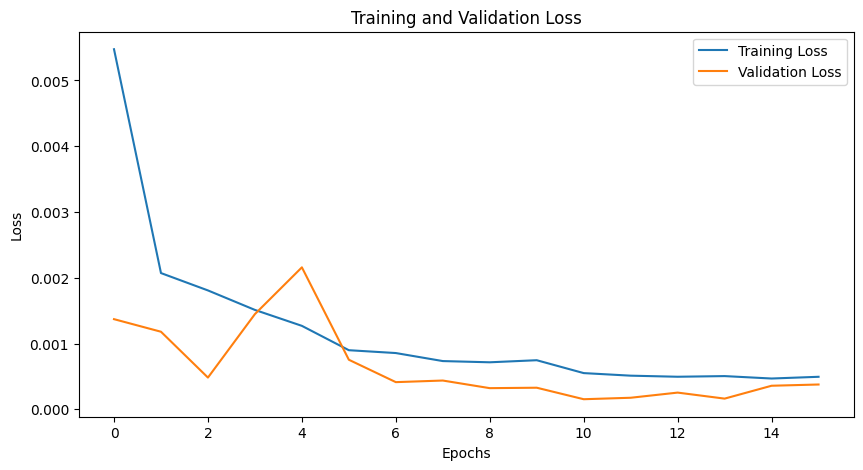

Test Reconstruction Loss: 0.0004, Test PSNR: 19.07 dB


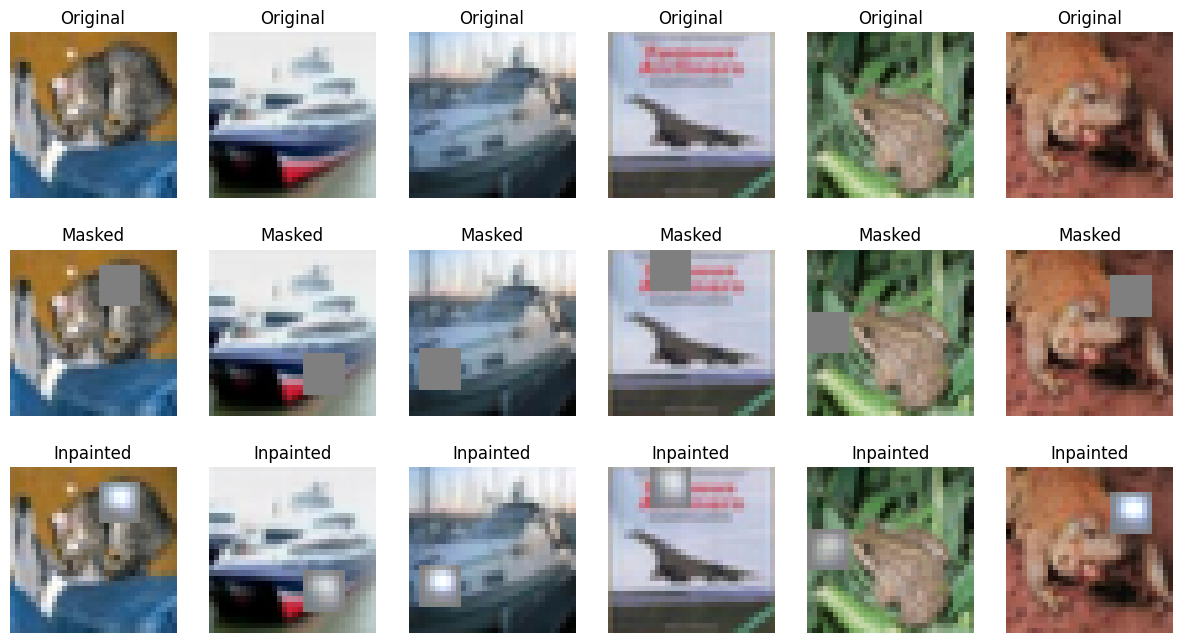

In [22]:
# Initialize the model, optimizer, and scheduler
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Train the model
train_losses, val_losses = train_model(model, train_loader, val_loader, optimizer, scheduler)

# Plot the losses
plot_losses(train_losses, val_losses)

# Evaluate the model on the test set
test_loss, test_psnr = evaluate_model(model, test_loader)
print(f"Test Reconstruction Loss: {test_loss:.4f}, Test PSNR: {test_psnr:.2f} dB")

# Show sample outputs
show_inpainted_images(model, test_loader)

# 7) Autoencoder for Image Inpainting

In [3]:
class InpaintingAutoencoder(nn.Module):
    def __init__(self):
        super(InpaintingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # Input: (3, 32, 32)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),  # Output: (64, 16, 16)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),  # Output: (128, 8, 8)

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2)  # Output: (256, 4, 4)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # Output: (256, 8, 8)

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # Output: (128, 16, 16)

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # Output: (64, 32, 32)

            nn.Conv2d(64, 3, kernel_size=3, padding=1),  # Output: (3, 32, 32)
            nn.Tanh()  # Ensure output values between -1 and 1
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [4]:
# Define training function
def train_model(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for images, _ in dataloader:
        # Apply random masks
        masked_images, masks = apply_random_mask(images)
        masked_images, masks = masked_images.to(device), masks.to(device)

        # Forward pass
        outputs = model(masked_images)
        loss = criterion(outputs * masks, images.to(device) * masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    return running_loss / len(dataloader)


# Define testing function
def test_model(model, dataloader, criterion, device):
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, _ in dataloader:
            masked_images, masks = apply_random_mask(images)
            masked_images, masks = masked_images.to(device), masks.to(device)

            outputs = model(masked_images)
            loss = criterion(outputs * masks, images.to(device) * masks)

            test_loss += loss.item()
    return test_loss / len(dataloader)

Epoch 1/25, Train Loss: 0.0785, Val Loss: 0.0402
Validation loss improved. Model saved.
Epoch 2/25, Train Loss: 0.0364, Val Loss: 0.0307
Validation loss improved. Model saved.
Epoch 3/25, Train Loss: 0.0291, Val Loss: 0.0246
Validation loss improved. Model saved.
Epoch 4/25, Train Loss: 0.0246, Val Loss: 0.0214
Validation loss improved. Model saved.
Epoch 5/25, Train Loss: 0.0222, Val Loss: 0.0194
Validation loss improved. Model saved.
Epoch 6/25, Train Loss: 0.0203, Val Loss: 0.0188
Validation loss improved. Model saved.
Epoch 7/25, Train Loss: 0.0185, Val Loss: 0.0160
Validation loss improved. Model saved.
Epoch 8/25, Train Loss: 0.0172, Val Loss: 0.0147
Validation loss improved. Model saved.
Epoch 9/25, Train Loss: 0.0164, Val Loss: 0.0155
No improvement for 1 epochs.
Epoch 10/25, Train Loss: 0.0153, Val Loss: 0.0139
Validation loss improved. Model saved.
Epoch 11/25, Train Loss: 0.0147, Val Loss: 0.0135
Validation loss improved. Model saved.
Epoch 12/25, Train Loss: 0.0142, Val Los

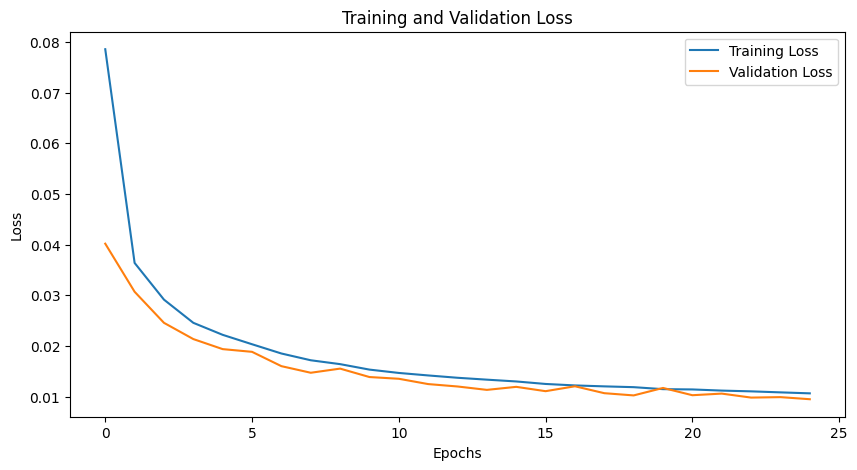

In [12]:
# Initialize model, criterion, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InpaintingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# Early stopping parameters
patience = 5
min_val_loss = float("inf")
no_improvement = 0

# Training loop
epochs = 25
train_losses, val_losses = [], []

for epoch in range(epochs):
    train_loss = train_model(model, train_loader, optimizer, criterion, device)
    val_loss = test_model(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Step scheduler
    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < min_val_loss:
        min_val_loss = val_loss
        no_improvement = 0
        torch.save(model.state_dict(), "best_inpainting_autoencoder.pth")
        print("Validation loss improved. Model saved.")
    else:
        no_improvement += 1
        print(f"No improvement for {no_improvement} epochs.")

    if no_improvement >= patience:
        print("Early stopping triggered.")
        break

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [13]:
def calculate_metrics(model, dataloader, device):
    model.eval()
    total_loss, total_psnr = 0.0, 0.0
    num_samples = 0

    with torch.no_grad():
        for images, _ in dataloader:
            masked_images, masks = apply_random_mask(images)
            masked_images, masks = masked_images.to(device), masks.to(device)

            outputs = model(masked_images)
            reconstruction_loss = criterion(outputs * masks, images.to(device) * masks)
            total_loss += reconstruction_loss.item() * images.size(0)

            # Calculate PSNR (Peak Signal-to-Noise Ratio)
            mse = F.mse_loss(outputs * masks, images.to(device) * masks)
            psnr = 20 * math.log10(1.0 / math.sqrt(mse.item()))  # Assumes normalized images (-1 to 1)
            total_psnr += psnr * images.size(0)

            num_samples += images.size(0)

    avg_loss = total_loss / num_samples
    avg_psnr = total_psnr / num_samples
    return avg_loss, avg_psnr

def plot_inpainting_results(model, dataloader, device, num_images=6):
    model.eval()
    images, _ = next(iter(dataloader))
    masked_images, masks = apply_random_mask(images.clone())
    images, masked_images, masks = images.to(device), masked_images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(masked_images)

    images = images[:num_images]
    masked_images = masked_images[:num_images]
    outputs = outputs[:num_images]

    fig, axes = plt.subplots(num_images, 3, figsize=(10, num_images * 3))
    for i in range(num_images):
        # Original
        axes[i, 0].imshow(np.transpose((images[i].cpu() / 2 + 0.5).numpy(), (1, 2, 0)))
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        # Masked
        axes[i, 1].imshow(np.transpose((masked_images[i].cpu() / 2 + 0.5).numpy(), (1, 2, 0)))
        axes[i, 1].set_title("Masked")
        axes[i, 1].axis("off")

        # Inpainted
        axes[i, 2].imshow(np.transpose((outputs[i].cpu() / 2 + 0.5).numpy(), (1, 2, 0)))
        axes[i, 2].set_title("Inpainted")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
avg_loss, avg_psnr = calculate_metrics(model, test_loader, device)
print(f"Average Reconstruction Loss: {avg_loss:.4f}")
print(f"Average PSNR: {avg_psnr:.2f} dB")

Average Reconstruction Loss: 0.0095
Average PSNR: 20.21 dB


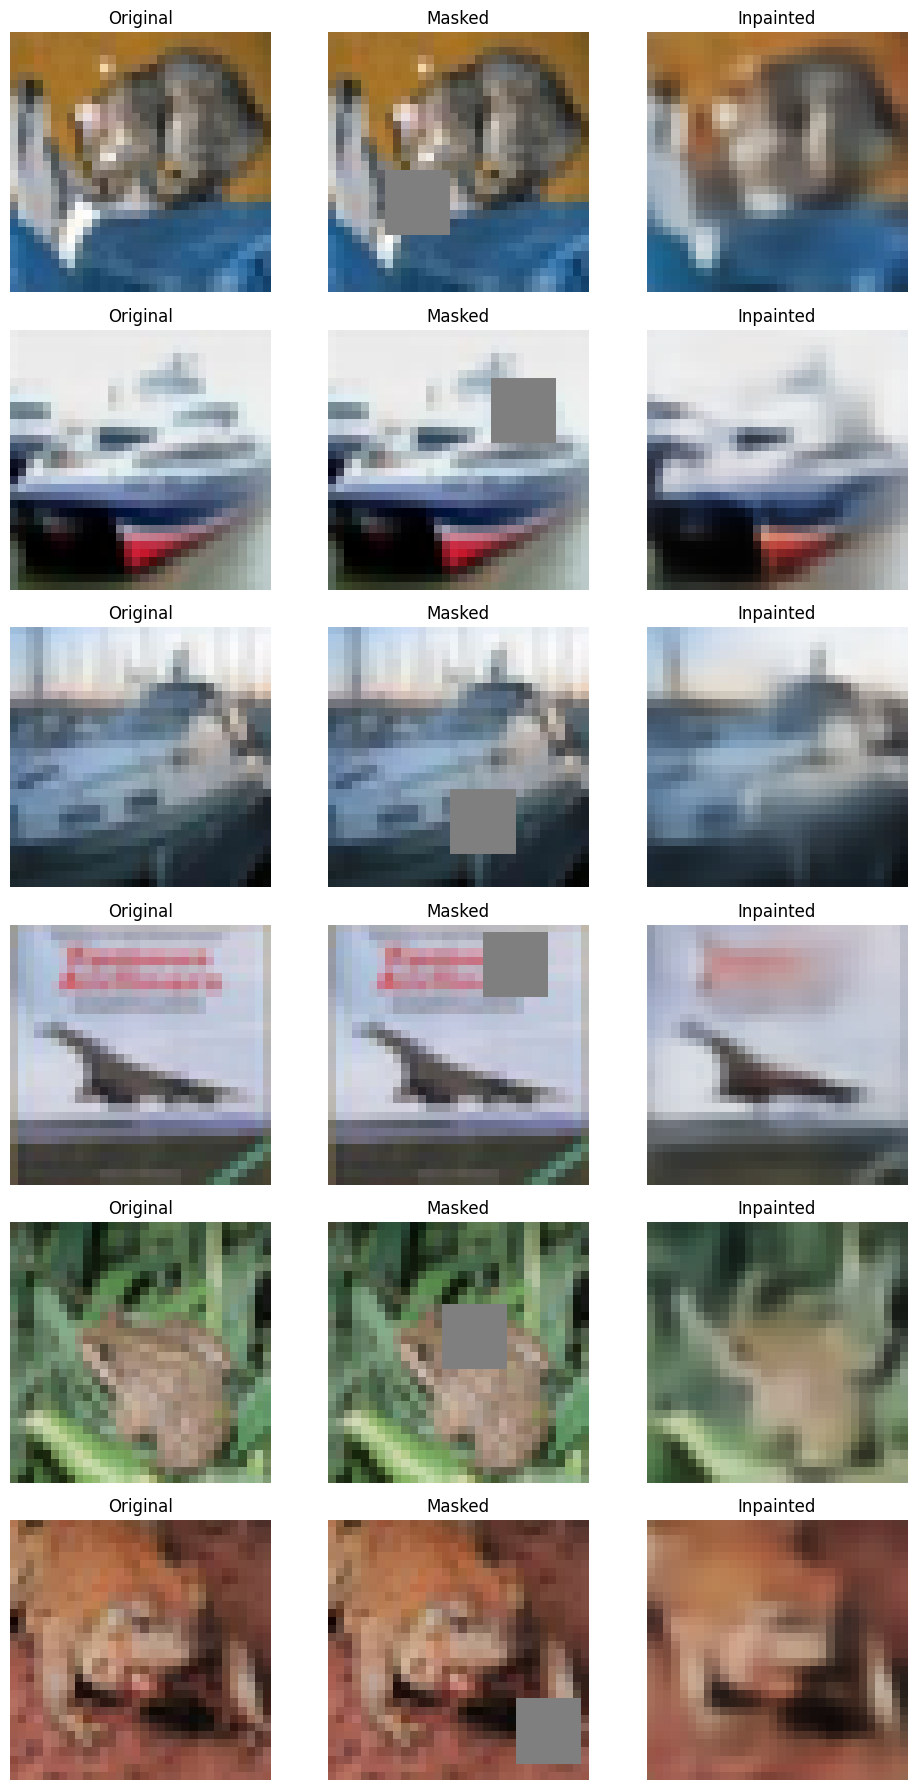

In [15]:
plot_inpainting_results(model, test_loader, device)

# 8) Partial Convolution Based Inpainting

In [5]:
class PartialConv(nn.Module):
    def __init__(self, in_filters, out_filters, kernel_size, strides=1, padding=0, dilation=1, groups=1, bias=True):
        super(PartialConv, self).__init__()

        padding = (kernel_size[0] // 2, kernel_size[1] // 2)
        self.input_conv = nn.Conv2d(in_filters, out_filters, kernel_size, strides, padding, bias=bias)
        self.mask_conv = nn.Conv2d(in_filters, out_filters, kernel_size, strides, padding, bias=False)
        
        self.window_size = kernel_size[0] * kernel_size[1]

        nn.init.constant_(self.mask_conv.weight, 1.0)

        for param in self.mask_conv.parameters():
            param.requires_grad = False

    def forward(self, input, mask):
        output = self.input_conv(input * mask)
        if self.input_conv.bias is not None:
            output_bias = self.input_conv.bias.view(1, -1, 1, 1).expand_as(output)
        else:
            output_bias = torch.zeros_like(output)

        with torch.no_grad():
            output_mask = self.mask_conv(mask)

        mask_ratio = self.window_size / (output_mask + 1e-8)

        output_mask = torch.clamp(output_mask, 0, 1)
  
        mask_ratio = mask_ratio * output_mask

        output = output * mask_ratio

        output = output + output_bias

        return output, output_mask

In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, in_filters, out_filters):
        super(EncoderLayer, self).__init__()
        self.p_conv_1 = PartialConv(in_filters, out_filters, (3, 3), strides=1)
        self.act_1 = nn.ReLU()
        self.p_conv_2 = PartialConv(out_filters, out_filters, (3, 3), strides=2)
        self.act_2 = nn.ReLU()

    def forward(self, inputs, masks):
        conv_out_1, mask_out_1 = self.p_conv_1(inputs, masks)
        conv_out_1 = self.act_1(conv_out_1)

        conv_out_2, mask_out_2 = self.p_conv_2(conv_out_1, mask_out_1)
        conv_out_2 = self.act_2(conv_out_2)

        return conv_out_1, mask_out_1, conv_out_2, mask_out_2

In [7]:
class DecoderLayer(nn.Module):
    def __init__(self, in_filters_1, in_filters_2):
        super(DecoderLayer, self).__init__()

        self.up_image = nn.Upsample(scale_factor=(2, 2))
        self.up_mask = nn.Upsample(scale_factor=(2, 2))
        
        self.p_conv_1 = PartialConv(in_filters_1 * 2, in_filters_1, (3, 3))
        self.act_1 = nn.LeakyReLU(negative_slope=0.2)
        self.p_conv_2 = PartialConv(in_filters_1, in_filters_2, (3, 3))
        self.act_2 = nn.LeakyReLU(negative_slope=0.2)

    def forward(self, in_image, in_mask, share_image, share_mask):
        up_out = self.up_image(in_image)
        mask_out = self.up_mask(in_mask)

        concat_image = torch.cat([share_image, up_out], axis=1)
        concat_mask = torch.cat([share_mask, mask_out], axis=1)

        conv_out_1, mask_out_1 = self.p_conv_1(concat_image, concat_mask)
        conv_out_1 = self.act_1(conv_out_1)
    
        conv_out_2, mask_out_2 = self.p_conv_2(conv_out_1, mask_out_1)
        conv_out_2 = self.act_2(conv_out_2)

        return conv_out_1, mask_out_1, conv_out_2, mask_out_2

In [12]:
# Define the model
class InpaintingModel(nn.Module):
    def __init__(self, input_dims=(32, 32), num_channels=3):
        super(InpaintingModel, self).__init__()
        # Encoder
        self.encoder_1 = EncoderLayer(num_channels, 32)
        self.encoder_2 = EncoderLayer(32, 64)
        self.encoder_3 = EncoderLayer(64, 128)
        self.encoder_4 = EncoderLayer(128, 256)

        # Decoder
        self.decoder_1 = DecoderLayer(256, 128)
        self.decoder_2 = DecoderLayer(128, 64)
        self.decoder_3 = DecoderLayer(64, 32)
        self.decoder_4 = DecoderLayer(32, 3)

        self.output_layer = nn.Sequential(
            nn.Conv2d(3, 3, (3, 3), padding=1),
            nn.Sigmoid()
        )

    def forward(self, inputs, masks):
        # Encoding
        conv_out_1, mask_out_1, conv_out_2, mask_out_2 = self.encoder_1(inputs, masks)
        conv_out_3, mask_out_3, conv_out_4, mask_out_4 = self.encoder_2(conv_out_2, mask_out_2)
        conv_out_5, mask_out_5, conv_out_6, mask_out_6 = self.encoder_3(conv_out_4, mask_out_4)
        conv_out_7, mask_out_7, conv_out_8, mask_out_8 = self.encoder_4(conv_out_6, mask_out_6)

        # Decoding
        conv_out_9, mask_out_9, conv_out_10, mask_out_10 = self.decoder_1(conv_out_8, mask_out_8, conv_out_7, mask_out_7)
        conv_out_11, mask_out_11, conv_out_12, mask_out_12 = self.decoder_2(conv_out_6, mask_out_6, conv_out_5, mask_out_5)
        conv_out_13, mask_out_13, conv_out_14, mask_out_14 = self.decoder_3(conv_out_4, mask_out_4, conv_out_3, mask_out_3)
        conv_out_15, mask_out_15, conv_out_16, mask_out_16 = self.decoder_4(conv_out_2, mask_out_2, conv_out_1, mask_out_1)

        outputs = self.output_layer(conv_out_16)
        return outputs

# Training function
def train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer, scheduler):
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, _ in train_loader:
            images, masks = apply_random_mask(images.clone())
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images, masks)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()
        train_losses.append(train_loss / len(train_loader))

        # Validation
        val_loss = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break

    return train_losses, val_losses

# Validation and testing function
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in loader:
            images, masks = apply_random_mask(images.clone())
            images, masks = images.to(device), masks.to(device)
            outputs = model(images, masks)
            loss = criterion(outputs, images)
            total_loss += loss.item()
    return total_loss / len(loader)


# Reconstruction loss and PSNR calculation
def calculate_metrics(model, loader):
    model.eval()
    total_loss = 0
    psnr_sum = 0
    with torch.no_grad():
        for images, _ in loader:
            images, masks = apply_random_mask(images.clone())
            images, masks = images.to(device), masks.to(device)
            outputs = model(images, masks)
            loss = F.mse_loss(outputs, images, reduction='sum')
            psnr = 10 * log10(1 / (loss.item() / images.numel()))
            total_loss += loss.item()
            psnr_sum += psnr
    avg_loss = total_loss / len(loader.dataset)
    avg_psnr = psnr_sum / len(loader)
    return avg_loss, avg_psnr

# Denormalization function
def denormalize(tensor):
    # Denormalize the image
    return tensor * 0.5 + 0.5

# Visualization function
def plot_results(model, loader):
    model.eval()
    images, _ = next(iter(loader))  # Get a batch of images
    original_images = images.clone()  # Make a copy to retain the original images
    
    images, masks = apply_random_mask(images.clone())  # Apply mask to the copy of the images
    masked_images = images * masks  # Masked images
    
    images, masks = images.to(device), masks.to(device)
    outputs = model(images, masks).cpu().detach()  # Inpainting output
    
    # Denormalize the images before plotting
    original_images = denormalize(original_images)
    masked_images = denormalize(masked_images)
    outputs = denormalize(outputs)
    
    fig, axes = plt.subplots(3, 6, figsize=(15, 10))
    for i in range(6):
        # Display original, masked, and inpainted images
        axes[0, i].imshow(ToPILImage()(original_images[i]))  # Use the copy for original images
        axes[1, i].imshow(ToPILImage()(masked_images[i]))
        axes[2, i].imshow(ToPILImage()(outputs[i]))
        
        axes[0, i].set_title("Original")
        axes[1, i].set_title("Masked")
        axes[2, i].set_title("Inpainted")
        
        for ax in axes[:, i]:
            ax.axis('off')
    plt.show()

Epoch 1/50, Train Loss: 0.2099, Val Loss: 0.1578
Epoch 2/50, Train Loss: 0.1545, Val Loss: 0.1520
Epoch 3/50, Train Loss: 0.1493, Val Loss: 0.1484
Epoch 4/50, Train Loss: 0.1471, Val Loss: 0.1469
Epoch 5/50, Train Loss: 0.1459, Val Loss: 0.1456
Epoch 6/50, Train Loss: 0.1442, Val Loss: 0.1422
Epoch 7/50, Train Loss: 0.1389, Val Loss: 0.1377
Epoch 8/50, Train Loss: 0.1366, Val Loss: 0.1369
Epoch 9/50, Train Loss: 0.1361, Val Loss: 0.1365
Epoch 10/50, Train Loss: 0.1357, Val Loss: 0.1362
Epoch 11/50, Train Loss: 0.1356, Val Loss: 0.1362
Epoch 12/50, Train Loss: 0.1355, Val Loss: 0.1359
Epoch 13/50, Train Loss: 0.1353, Val Loss: 0.1359
Epoch 14/50, Train Loss: 0.1352, Val Loss: 0.1357
Epoch 15/50, Train Loss: 0.1351, Val Loss: 0.1356
Epoch 16/50, Train Loss: 0.1350, Val Loss: 0.1355
Epoch 17/50, Train Loss: 0.1348, Val Loss: 0.1354
Epoch 18/50, Train Loss: 0.1347, Val Loss: 0.1351
Epoch 19/50, Train Loss: 0.1347, Val Loss: 0.1352
Epoch 20/50, Train Loss: 0.1345, Val Loss: 0.1350
Epoch 21/

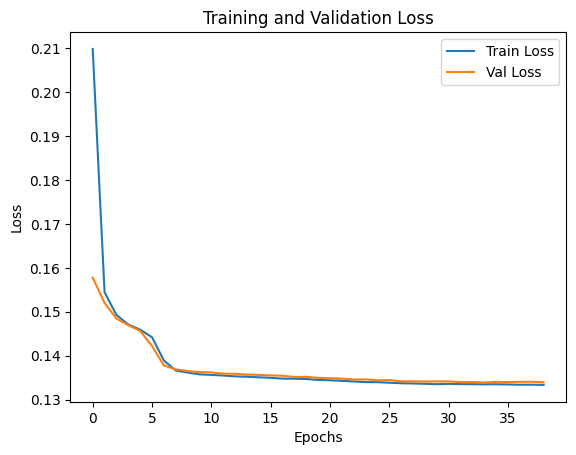

Test Reconstruction Loss: 400.8704, PSNR: 8.8637


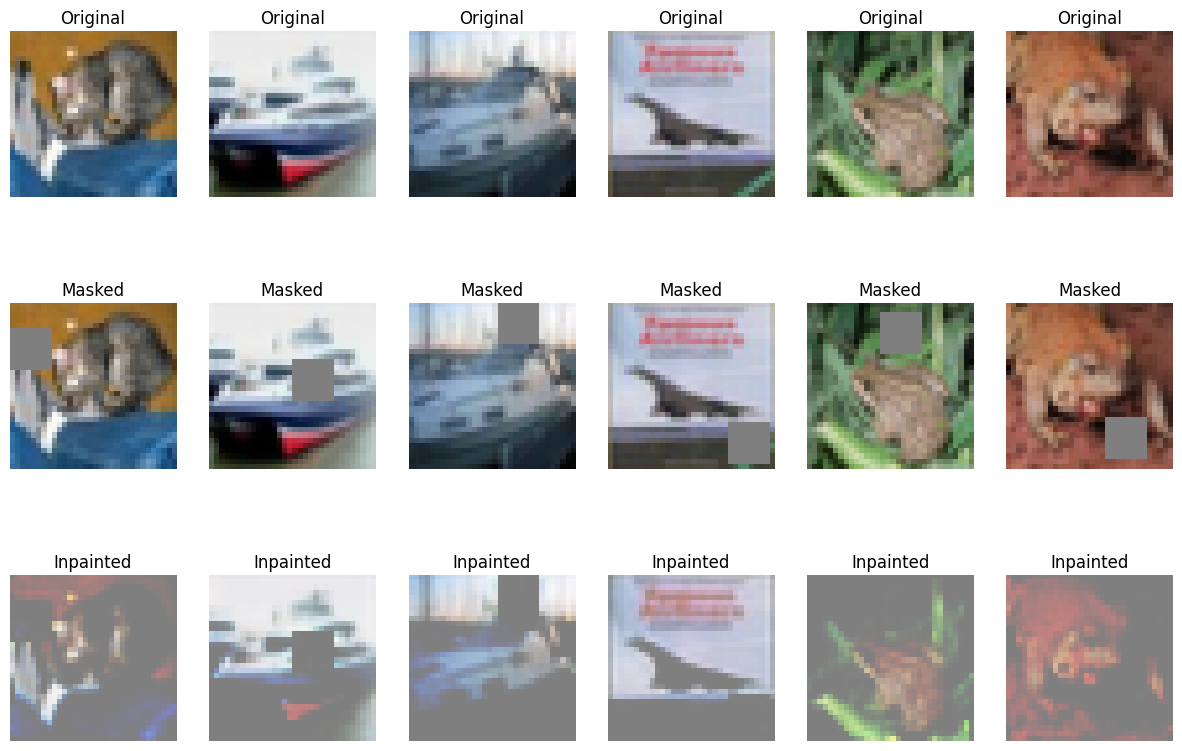

In [13]:
# Training the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InpaintingModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 50
train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer, scheduler)

# Plotting losses
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# Evaluate on the test set
avg_loss, avg_psnr = calculate_metrics(model, test_loader)
print(f"Test Reconstruction Loss: {avg_loss:.4f}, PSNR: {avg_psnr:.4f}")

# Visualize some results
plot_results(model, test_loader)

# 9) Partial Convolution U-Net

In [22]:
class PartialConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, bn=True, bias=False, sample="none-3", activation="relu"):
        super().__init__()
        self.bn = bn
        self.activation = activation

        if sample.startswith("down"):
            kernel_size = int(sample.split("-")[1])
            self.input_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=2, padding=kernel_size // 2, bias=bias)
            self.mask_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=2, padding=kernel_size // 2, bias=False)
        else:
            self.input_conv = nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=bias)
            self.mask_conv = nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False)

        nn.init.constant_(self.mask_conv.weight, 1.0)
        nn.init.kaiming_normal_(self.input_conv.weight, mode="fan_in")

        for param in self.mask_conv.parameters():
            param.requires_grad = False

        if bn:
            self.batch_normalization = nn.BatchNorm2d(out_channels)

        if activation == "relu":
            self.activation = nn.ReLU()
        elif activation == "leaky_relu":
            self.activation = nn.LeakyReLU(0.2)

    def forward(self, x, mask):
        output = self.input_conv(x * mask)
        with torch.no_grad():
            output_mask = self.mask_conv(mask)

        mask_zero = (output_mask == 0)
        output_bias = self.input_conv.bias.view(1, -1, 1, 1).expand_as(output) if self.input_conv.bias is not None else 0
        mask_sum = output_mask.masked_fill(mask_zero, 1.0)
        output = (output - output_bias) / mask_sum + output_bias
        output.masked_fill_(mask_zero, 0.0)

        new_mask = torch.ones_like(output).masked_fill(mask_zero, 0.0)
        if self.bn:
            output = self.batch_normalization(output)
        if self.activation:
            output = self.activation(output)
        return output, new_mask

class PartialConvUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder with additional layers
        self.encoder_1 = PartialConvLayer(3, 64, bn=False, sample="down-7")  # Input layer
        self.encoder_2 = PartialConvLayer(64, 128, sample="down-5")         # Down-sampling 1
        self.encoder_3 = PartialConvLayer(128, 256, sample="down-3")       # Down-sampling 2
        self.encoder_4 = PartialConvLayer(256, 512, sample="down-3")       # Down-sampling 3
        self.encoder_5 = PartialConvLayer(512, 1024, sample="down-3")      # Additional depth

        # Bottleneck with residual connection
        self.bottleneck = PartialConvLayer(1024, 1024, activation="relu")  

        # Decoder with additional layers
        self.decoder_5 = PartialConvLayer(1024 + 512, 512, activation="leaky_relu")  # Decoder for encoder_5
        self.decoder_4 = PartialConvLayer(512 + 256, 256, activation="leaky_relu")  # Decoder for encoder_4
        self.decoder_3 = PartialConvLayer(256 + 128, 128, activation="leaky_relu")  # Decoder for encoder_3
        self.decoder_2 = PartialConvLayer(128 + 64, 64, activation="leaky_relu")   # Decoder for encoder_2
        self.decoder_1 = PartialConvLayer(64 + 3, 3, bn=False, activation=None, bias=True)  # Final output layer

    def forward(self, x, mask):
        # Encoder forward pass
        e1, m1 = self.encoder_1(x, mask)
        e2, m2 = self.encoder_2(e1, m1)
        e3, m3 = self.encoder_3(e2, m2)
        e4, m4 = self.encoder_4(e3, m3)
        e5, m5 = self.encoder_5(e4, m4)

        # Bottleneck
        b, bm = self.bottleneck(e5, m5)

        # Decoder forward pass with skip connections
        d5, dm5 = self.decoder_5(torch.cat([F.interpolate(b, scale_factor=2), e4], dim=1),
                                 torch.cat([F.interpolate(bm, scale_factor=2), m4], dim=1))
        d4, dm4 = self.decoder_4(torch.cat([F.interpolate(d5, scale_factor=2), e3], dim=1),
                                 torch.cat([F.interpolate(dm5, scale_factor=2), m3], dim=1))
        d3, dm3 = self.decoder_3(torch.cat([F.interpolate(d4, scale_factor=2), e2], dim=1),
                                 torch.cat([F.interpolate(dm4, scale_factor=2), m2], dim=1))
        d2, dm2 = self.decoder_2(torch.cat([F.interpolate(d3, scale_factor=2), e1], dim=1),
                                 torch.cat([F.interpolate(dm3, scale_factor=2), m1], dim=1))
        d1, _ = self.decoder_1(torch.cat([F.interpolate(d2, scale_factor=2), x], dim=1),
                               torch.cat([F.interpolate(dm2, scale_factor=2), mask], dim=1))

        return d1

In [23]:
def train_model(model, train_loader, val_loader, num_epochs=50, patience=5, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    criterion = nn.MSELoss()
    
    best_loss = float('inf')
    patience_counter = 0

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, _ in train_loader:
            images, masks = apply_random_mask(images)
            images, masks = images.to(device), masks.to(device)

            outputs = model(images, masks)
            loss = criterion(outputs, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, _ in val_loader:
                images, masks = apply_random_mask(images)
                images, masks = images.to(device), masks.to(device)
                outputs = model(images, masks)
                loss = criterion(outputs, images)
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

        # Early Stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break

    return train_losses, val_losses

def test_model(model, test_loader):
    model.eval()
    criterion = nn.MSELoss()
    total_loss = 0
    psnr_total = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images, masks = apply_random_mask(images)
            images, masks = images.to(device), masks.to(device)
            outputs = model(images, masks)
            loss = criterion(outputs, images)
            total_loss += loss.item()

            mse = F.mse_loss(outputs, images)
            psnr = 10 * torch.log10(1 / mse)
            psnr_total += psnr.item()

    avg_loss = total_loss / len(test_loader)
    avg_psnr = psnr_total / len(test_loader)
    return avg_loss, avg_psnr

def plot_results(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.show()

def visualize_outputs(model, test_loader):
    model.eval()
    images, _ = next(iter(test_loader))
    masked_images, masks = apply_random_mask(images.clone())
    images, masked_images, masks = images.to(device), masked_images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(masked_images, masks)

    fig, axes = plt.subplots(5, 3, figsize=(10, 15))
    for i in range(5):
        axes[i, 0].imshow(np.transpose(images[i].cpu().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[i, 0].set_title("Original")
        axes[i, 1].imshow(np.transpose(masked_images[i].cpu().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[i, 1].set_title("Masked")
        axes[i, 2].imshow(np.transpose(outputs[i].cpu().numpy() / 2 + 0.5, (1, 2, 0)))
        axes[i, 2].set_title("Inpainted")
    plt.tight_layout()
    plt.show()

Epoch 1/50, Train Loss: 0.0979, Val Loss: 0.0446
Epoch 2/50, Train Loss: 0.0354, Val Loss: 0.0256
Epoch 3/50, Train Loss: 0.0235, Val Loss: 0.0200
Epoch 4/50, Train Loss: 0.0197, Val Loss: 0.0173
Epoch 5/50, Train Loss: 0.0168, Val Loss: 0.0146
Epoch 6/50, Train Loss: 0.0149, Val Loss: 0.0135
Epoch 7/50, Train Loss: 0.0140, Val Loss: 0.0130
Epoch 8/50, Train Loss: 0.0132, Val Loss: 0.0120
Epoch 9/50, Train Loss: 0.0126, Val Loss: 0.0116
Epoch 10/50, Train Loss: 0.0119, Val Loss: 0.0111
Epoch 11/50, Train Loss: 0.0114, Val Loss: 0.0107
Epoch 12/50, Train Loss: 0.0106, Val Loss: 0.0099
Epoch 13/50, Train Loss: 0.0094, Val Loss: 0.0084
Epoch 14/50, Train Loss: 0.0084, Val Loss: 0.0075
Epoch 15/50, Train Loss: 0.0074, Val Loss: 0.0065
Epoch 16/50, Train Loss: 0.0065, Val Loss: 0.0060
Epoch 17/50, Train Loss: 0.0059, Val Loss: 0.0053
Epoch 18/50, Train Loss: 0.0054, Val Loss: 0.0048
Epoch 19/50, Train Loss: 0.0049, Val Loss: 0.0045
Epoch 20/50, Train Loss: 0.0045, Val Loss: 0.0042
Epoch 21/

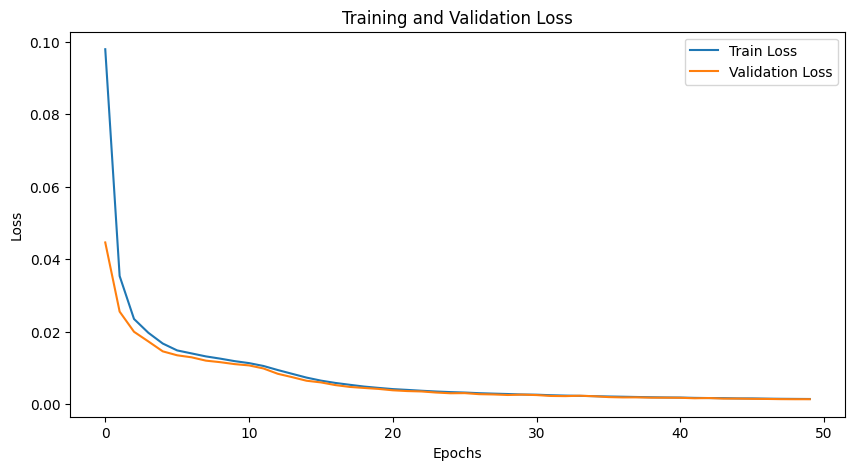

Test Loss: 0.0014, Test PSNR: 28.5504


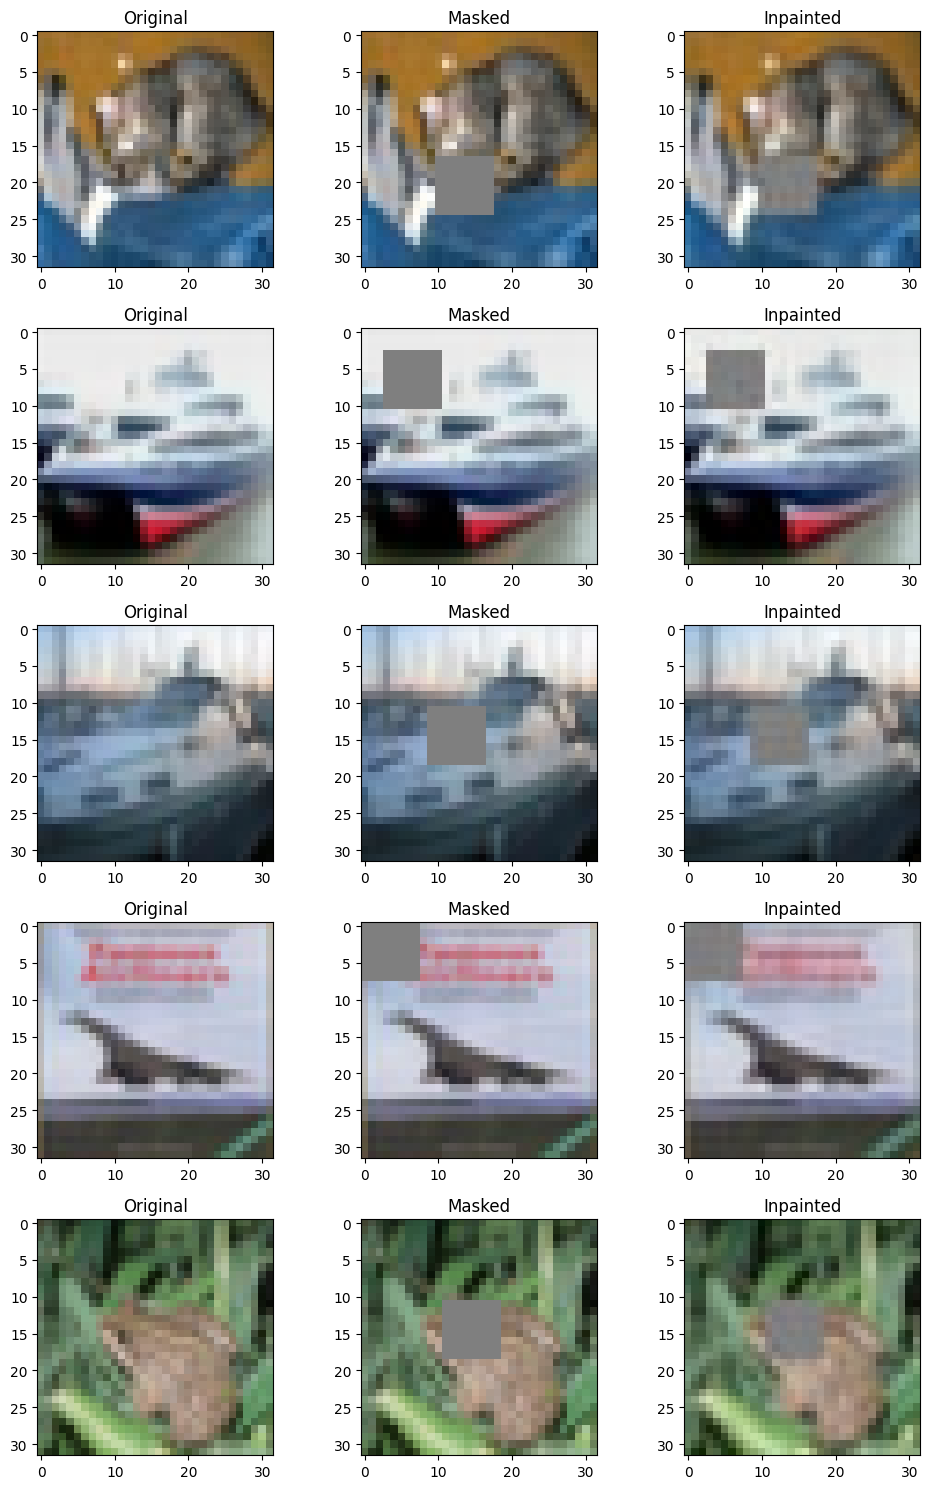

In [24]:
model = PartialConvUNet().to(device)
train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs=50, patience=5, lr=1e-3)
plot_results(train_losses, val_losses)
test_loss, test_psnr = test_model(model, test_loader)
print(f"Test Loss: {test_loss:.4f}, Test PSNR: {test_psnr:.4f}")
visualize_outputs(model, test_loader)

# 10) Pixel CNN

Files already downloaded and verified
Files already downloaded and verified
Epoch 1/50, Train Loss: 0.9292, Val Loss: 0.8939
Epoch 2/50, Train Loss: 0.8864, Val Loss: 0.8745
Epoch 3/50, Train Loss: 0.8728, Val Loss: 0.8739
Epoch 4/50, Train Loss: 0.8665, Val Loss: 0.8662
Epoch 5/50, Train Loss: 0.8604, Val Loss: 0.8642
Epoch 6/50, Train Loss: 0.8567, Val Loss: 0.8600
Epoch 7/50, Train Loss: 0.8525, Val Loss: 0.8507
Epoch 8/50, Train Loss: 0.8486, Val Loss: 0.8510
Epoch 9/50, Train Loss: 0.8464, Val Loss: 0.8527
Epoch 10/50, Train Loss: 0.8440, Val Loss: 0.8415
Epoch 11/50, Train Loss: 0.8427, Val Loss: 0.8459
Epoch 12/50, Train Loss: 0.8404, Val Loss: 0.8374
Epoch 13/50, Train Loss: 0.8388, Val Loss: 0.8431
Epoch 14/50, Train Loss: 0.8375, Val Loss: 0.8401
Epoch 15/50, Train Loss: 0.8360, Val Loss: 0.8495
Epoch 16/50, Train Loss: 0.8310, Val Loss: 0.8285
Epoch 17/50, Train Loss: 0.8316, Val Loss: 0.8307
Epoch 18/50, Train Loss: 0.8306, Val Loss: 0.8303
Epoch 19/50, Train Loss: 0.8293, 

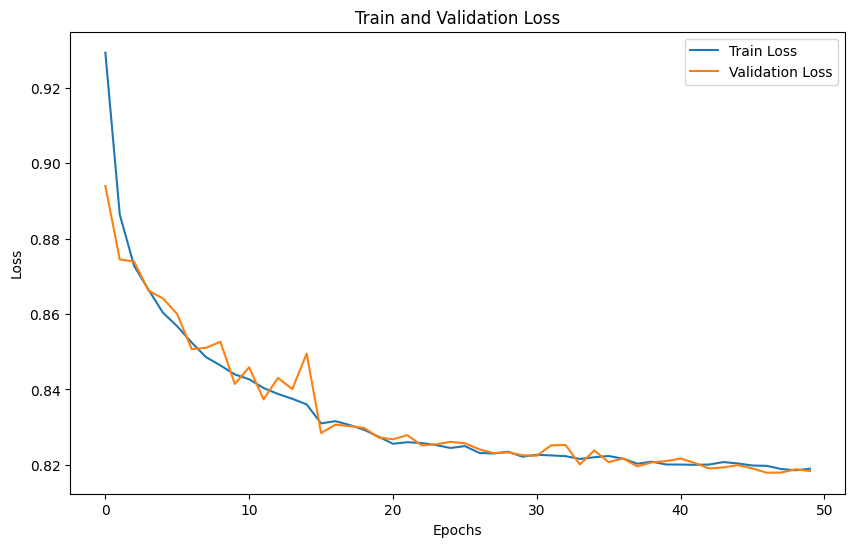

Final Test Loss: 0.8210
Average PSNR: 29.86 dB


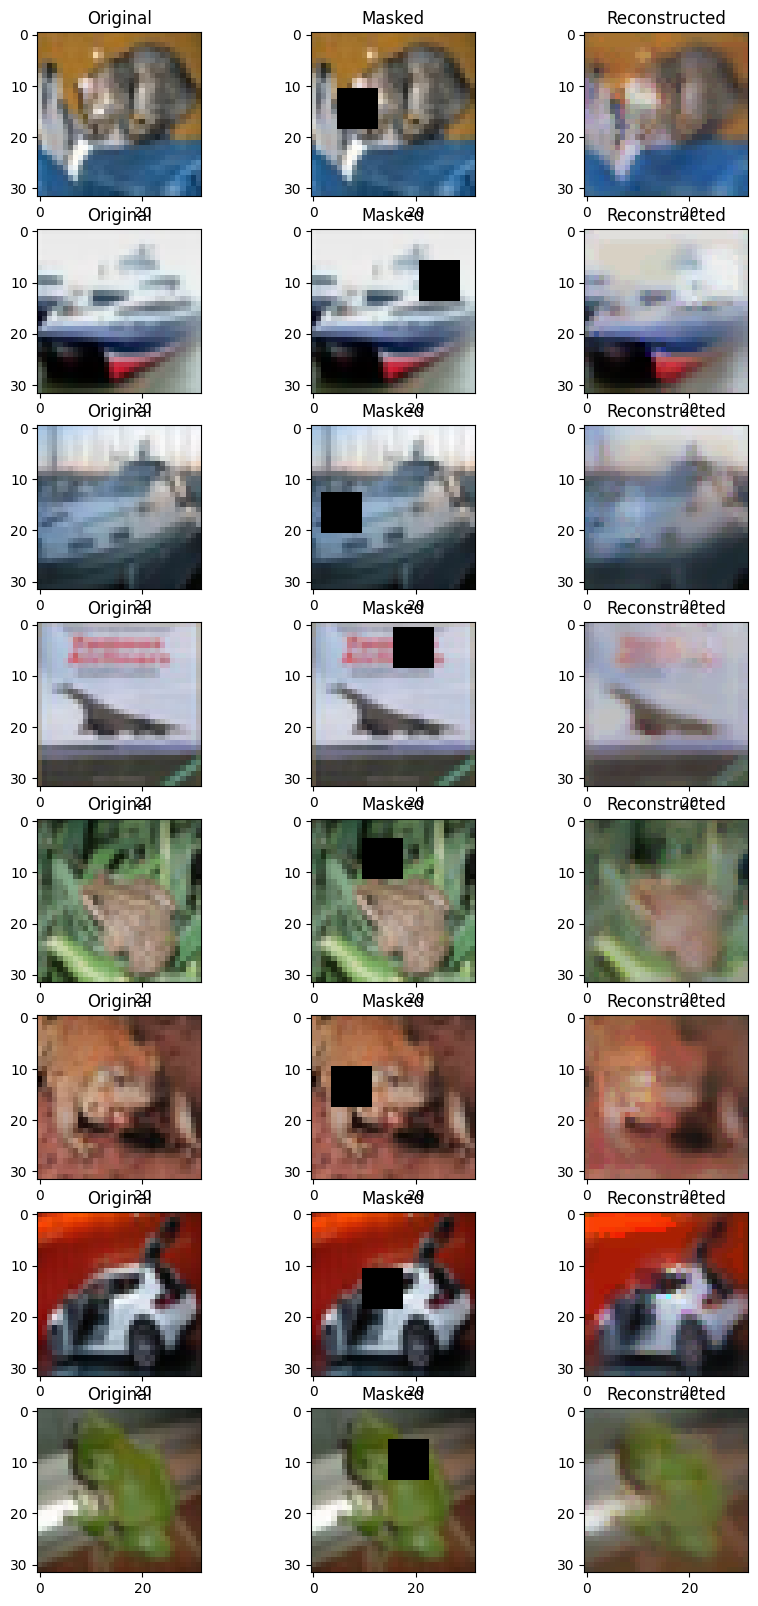

In [23]:
# PixelCNN Model
class PixelCNN(nn.Module):
    def __init__(self):
        super(PixelCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, padding=3)
        self.residual = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=1)
        )
        self.final_layers = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(64, 256 * 3, kernel_size=1)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        for _ in range(3):
            x = self.residual(x) + x
        x = self.final_layers(x)
        logits_r, logits_g, logits_b = torch.chunk(x, chunks=3, dim=1)
        return logits_r, logits_g, logits_b

# Random Masking Function
def apply_random_mask(images, mask_size=8):
    mask = torch.ones_like(images)
    for i in range(images.size(0)):
        x, y = np.random.randint(0, images.size(2) - mask_size), np.random.randint(0, images.size(3) - mask_size)
        mask[i, :, x:x+mask_size, y:y+mask_size] = 0
        images[i, :, x:x+mask_size, y:y+mask_size] = 0
    return images, mask

# Training Function
def train_model(model, train_loader, val_loader, num_epochs, device, patience=5, mask_size=8):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss(reduction='none')  # Element-wise loss for masking
    model = model.to(device)

    history = {"train_loss": [], "val_loss": []}
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            masked_images, mask = apply_random_mask(images.clone(), mask_size)
            mask = mask.to(device)

            logits_r, logits_g, logits_b = model(masked_images)
            labels_r = (images[:, 0] * 255).long()
            labels_g = (images[:, 1] * 255).long()
            labels_b = (images[:, 2] * 255).long()

            loss_r = criterion(logits_r.permute(0, 2, 3, 1).reshape(-1, 256), labels_r.view(-1))
            loss_g = criterion(logits_g.permute(0, 2, 3, 1).reshape(-1, 256), labels_g.view(-1))
            loss_b = criterion(logits_b.permute(0, 2, 3, 1).reshape(-1, 256), labels_b.view(-1))

            # Masked loss
            loss_r = (loss_r.view_as(labels_r) * (1 - mask[:, 0])).mean()
            loss_g = (loss_g.view_as(labels_g) * (1 - mask[:, 1])).mean()
            loss_b = (loss_b.view_as(labels_b) * (1 - mask[:, 2])).mean()

            loss = loss_r + loss_g + loss_b
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        history["train_loss"].append(train_loss)
        val_loss = validate_model(model, val_loader, criterion, device, mask_size)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "best_pixelcnn.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break

    return model, history

# Plotting Training and Validation Loss
def plot_loss(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train and Validation Loss')
    plt.legend()
    plt.show()
    
# Validation Function
def validate_model(model, val_loader, criterion, device, mask_size):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            masked_images, mask = apply_random_mask(images.clone(), mask_size)
            mask = mask.to(device)

            logits_r, logits_g, logits_b = model(masked_images)
            labels_r = (images[:, 0] * 255).long()
            labels_g = (images[:, 1] * 255).long()
            labels_b = (images[:, 2] * 255).long()

            loss_r = criterion(logits_r.permute(0, 2, 3, 1).reshape(-1, 256), labels_r.view(-1))
            loss_g = criterion(logits_g.permute(0, 2, 3, 1).reshape(-1, 256), labels_g.view(-1))
            loss_b = criterion(logits_b.permute(0, 2, 3, 1).reshape(-1, 256), labels_b.view(-1))

            loss_r = (loss_r.view_as(labels_r) * (1 - mask[:, 0])).mean()
            loss_g = (loss_g.view_as(labels_g) * (1 - mask[:, 1])).mean()
            loss_b = (loss_b.view_as(labels_b) * (1 - mask[:, 2])).mean()

            val_loss += loss_r.item() + loss_g.item() + loss_b.item()

    return val_loss / len(val_loader)

# Visualization Function
def visualize_inpainting(model, data_loader, device, mask_size=8):
    model.eval()
    images, _ = next(iter(data_loader))
    images = images[:8].to(device)  # Select 8 samples
    masked_images, _ = apply_random_mask(images.clone(), mask_size)

    with torch.no_grad():
        logits_r, logits_g, logits_b = model(masked_images)
        pred_r = torch.argmax(logits_r, dim=1).float() / 255
        pred_g = torch.argmax(logits_g, dim=1).float() / 255
        pred_b = torch.argmax(logits_b, dim=1).float() / 255
        reconstructed = torch.stack([pred_r, pred_g, pred_b], dim=1)

    # Plot original, masked, and reconstructed images
    fig, axes = plt.subplots(8, 3, figsize=(10, 20))
    for i in range(8):
        axes[i, 0].imshow(images[i].permute(1, 2, 0).cpu())
        axes[i, 0].set_title("Original")
        axes[i, 1].imshow(masked_images[i].permute(1, 2, 0).cpu())
        axes[i, 1].set_title("Masked")
        axes[i, 2].imshow(reconstructed[i].permute(1, 2, 0).cpu())
        axes[i, 2].set_title("Reconstructed")
    plt.show()

# PSNR Calculation Function
def calculate_psnr(pred, target, mask):
    mse = F.mse_loss(pred * (1 - mask), target * (1 - mask), reduction='mean')
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()

# Testing Function with PSNR
def test_model_with_psnr(model, test_loader, criterion, device, mask_size=8):
    model.eval()
    test_loss = 0
    total_psnr = 0
    num_batches = 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            masked_images, mask = apply_random_mask(images.clone(), mask_size)
            mask = mask.to(device)

            logits_r, logits_g, logits_b = model(masked_images)

            # Convert logits to predicted images (normalized to [0, 1])
            pred_r = logits_r.argmax(dim=1).float() / 255.0
            pred_g = logits_g.argmax(dim=1).float() / 255.0
            pred_b = logits_b.argmax(dim=1).float() / 255.0

            preds = torch.cat([pred_r.unsqueeze(1), pred_g.unsqueeze(1), pred_b.unsqueeze(1)], dim=1)

            # Compute Loss
            labels_r = (images[:, 0] * 255).long()
            labels_g = (images[:, 1] * 255).long()
            labels_b = (images[:, 2] * 255).long()

            loss_r = criterion(logits_r.permute(0, 2, 3, 1).reshape(-1, 256), labels_r.view(-1))
            loss_g = criterion(logits_g.permute(0, 2, 3, 1).reshape(-1, 256), labels_g.view(-1))
            loss_b = criterion(logits_b.permute(0, 2, 3, 1).reshape(-1, 256), labels_b.view(-1))

            loss_r = (loss_r.view_as(labels_r) * (1 - mask[:, 0])).mean()
            loss_g = (loss_g.view_as(labels_g) * (1 - mask[:, 1])).mean()
            loss_b = (loss_b.view_as(labels_b) * (1 - mask[:, 2])).mean()

            test_loss += loss_r.item() + loss_g.item() + loss_b.item()

            # Compute PSNR
            total_psnr += calculate_psnr(preds, images, mask)
            num_batches += 1

    test_loss /= len(test_loader)
    avg_psnr = total_psnr / num_batches
    return test_loss, avg_psnr

# Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PixelCNN()
trained_model, history = train_model(model, train_loader, test_loader, num_epochs=50, device=device)

plot_loss(history)

# Run Testing with PSNR
test_loss, avg_psnr = test_model_with_psnr(trained_model, test_loader, nn.CrossEntropyLoss(reduction='none'), device)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Average PSNR: {avg_psnr:.2f} dB")

# Visualize Results
visualize_inpainting(trained_model, test_loader, device)
